# EDA & Preprocessing — Gaia Crop Volatility Dataset

**Purpose:** Exploratory Data Analysis and preprocessing pipeline that prepares the dataset for PCMCI causal discovery with three conditional independence tests:
- `PCMCI + ParCorr` — linear, Gaussian dependencies
- `PCMCI + GPDCtorch` — nonlinear additive dependencies
- `PCMCI + FAISSCMI` — fully nonparametric (any dependencies)

This notebook follows the tigramite tutorial workflow:
1. Inspect raw data (shape, NaNs, dtypes)
2. Analyse distributions (skewness, kurtosis, normality tests)
3. Detect and remove trends (CO₂, DJIA, Broad Dollar)
4. Detect and remove seasonality (temperature, precipitation, EVAP)
5. Gaussianise via rank-based transform (`pp.trafo2normal`)
6. Plot lagged dependencies to select `tau_max`
7. Plot scatter / density plots to justify CI test choice
8. Check stationarity post-preprocessing
9. Export clean arrays ready for PCMCI

**Data:** `data/{weekly,monthly}/{corn,soybean,wheat}.csv`  
**Period:** April 2009 – March 2025  
**Samples:** 832 weeks / 192 months

## 0. Imports & Configuration

In [2]:
import sys
from pathlib import Path

ROOT = Path('.').resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as mticker
from scipy import stats

import tigramite
from tigramite import data_processing as pp
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Configuration ────────────────────────────────────────────────────────────
CROP      = 'corn'      # 'corn' | 'soybean' | 'wheat'
FREQUENCY = 'monthly'    # 'weekly' | 'monthly'
CYCLE_LEN = 52 if FREQUENCY == 'weekly' else 12  # one year in time steps
TAU_MAX_INSPECT = 20    # lags to explore during EDA

DATA_PATH = ROOT / 'data' / FREQUENCY / f'{CROP}.csv'
print(f'Analysing: {DATA_PATH}')

Analysing: /Users/arshia/Projects/Papers/FinancialAI/Gaia/data/monthly/corn.csv


## 1. Load & Inspect Raw Data

In [3]:
raw = pd.read_csv(DATA_PATH, parse_dates=['date'])
print(f'Shape : {raw.shape}')
print(f'Period: {raw["date"].min().date()}  →  {raw["date"].max().date()}')
print(f'Columns ({len(raw.columns)}):  {list(raw.columns)}')

Shape : (192, 23)
Period: 2009-04-01  →  2025-03-01
Columns (23):  ['date', 'weekly_rv', 'prcp', 'awnd', 'tmin', 'tmax', 'co2', 'pdsi', 'frbsf_sentiment', 'epu_index', 'DJIA_Index', 'WTI_Index', 'Broad_Dollar_index', 'Stock_Uncertainty', 'Text_Climate_Anomaly', 'EVAP', 'soil_moisture_mean_m3m3', 'cloud_cover_mean_pct', 'humidity_mean_pct', 'ssta_elino', 'ssta_lanina', 'SOI_index', 'NAO_index']


In [4]:
# ── Feature groups (mirrors src/dataset/feature.py) ──────────────────────────
FEATURE_GROUPS = {
    'rv'          : ['weekly_rv'],
    'climate_raw' : ['prcp', 'awnd', 'tmin', 'tmax', 'co2', 'pdsi',
                     'EVAP', 'soil_moisture_mean_m3m3', 'cloud_cover_mean_pct', 'humidity_mean_pct',
                     'ssta_elino', 'ssta_lanina', 'SOI_index', 'NAO_index'],
    'macro'       : ['DJIA_Index', 'WTI_Index', 'Broad_Dollar_index', 'Stock_Uncertainty'],
    'news'        : ['Text_Climate_Anomaly', 'frbsf_sentiment', 'epu_index'],
}

# Colour per group
GROUP_COLORS = {
    'rv': '#e41a1c', 'climate_raw': '#377eb8', 'macro': '#4daf4a',
    'news': '#984ea3', 'epu_detail': '#ff7f00'
}

def group_of(col):
    for g, cols in FEATURE_GROUPS.items():
        if col in cols:
            return g
    return 'other'

FEATURE_COLS = [c for c in raw.columns if c != 'date']
print('Feature groups:')
for g, cols in FEATURE_GROUPS.items():
    print(f'  {g:15s} ({len(cols):2d}): {cols}')

Feature groups:
  rv              ( 1): ['weekly_rv']
  climate_raw     (14): ['prcp', 'awnd', 'tmin', 'tmax', 'co2', 'pdsi', 'EVAP', 'soil_moisture_mean_m3m3', 'cloud_cover_mean_pct', 'humidity_mean_pct', 'ssta_elino', 'ssta_lanina', 'SOI_index', 'NAO_index']
  macro           ( 4): ['DJIA_Index', 'WTI_Index', 'Broad_Dollar_index', 'Stock_Uncertainty']
  news            ( 3): ['Text_Climate_Anomaly', 'frbsf_sentiment', 'epu_index']


In [5]:
# ── Missing value analysis ────────────────────────────────────────────────────
nan_counts = raw[FEATURE_COLS].isnull().sum()
nan_pct    = (nan_counts / len(raw) * 100).round(1)

nan_df = pd.DataFrame({'count': nan_counts, 'pct': nan_pct})
nan_df = nan_df[nan_df['count'] > 0].sort_values('count', ascending=False)

if nan_df.empty:
    print('No missing values in this dataset.')
else:
    fig, ax = plt.subplots(figsize=(7, max(2, len(nan_df) * 0.5)))
    colors = [GROUP_COLORS.get(group_of(c), '#888') for c in nan_df.index]
    bars = ax.barh(nan_df.index, nan_df['pct'], color=colors)
    ax.set_xlabel('Missing (%)')
    ax.set_title(f'Missing values — {CROP} {FREQUENCY}')
    for bar, (idx, row) in zip(bars, nan_df.iterrows()):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{int(row["count"])} rows', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    print(nan_df)

No missing values in this dataset.


### 1.1 Missing Value Treatment

| Column | # NaN | Strategy | Reason |
|--------|-------|----------|--------|
| `pdsi` | 32 | Linear interpolation | Continuous drought index with short gaps |
| `DJIA_Index` | 1 | Forward-fill | Single isolated gap |
| `Broad_Dollar_index` | 109 | Linear interpolation | Larger gap at series start; trend-like variable |

After imputation we drop any remaining rows with NaN to guarantee a complete rectangular array for tigramite.

In [6]:
df = raw.copy().sort_values('date').reset_index(drop=True)

# Interpolate slowly-varying / continuous variables
for col in ['pdsi', 'Broad_Dollar_index']:
    if col in df.columns:
        df[col] = df[col].interpolate(method='linear', limit_direction='both')

# Forward-fill isolated single gaps
for col in ['DJIA_Index']:
    if col in df.columns:
        df[col] = df[col].ffill().bfill()

df_clean = df.dropna().reset_index(drop=True)
print(f'Rows after imputation + dropna: {len(df_clean)}  (dropped {len(df) - len(df_clean)})')
print(f'Remaining NaNs: {df_clean[FEATURE_COLS].isnull().sum().sum()}')

Rows after imputation + dropna: 192  (dropped 0)
Remaining NaNs: 0


## 2. Univariate Distribution Analysis

We plot each feature's histogram and check normality to decide which CI test needs Gaussianisation.

**Decision rule:**
- Shapiro-Wilk p < 0.05 **and** skewness > |0.5| → apply `pp.trafo2normal`
- `ParCorr` on Gaussianised data ≈ `RobustParCorr` (rank-based prior to test)
- `GPDCtorch` is robust to non-Gaussian marginals (uses GP regression) but benefits from Gaussianisation
- `FAISSCMI` standardises internally; trafo2normal still improves kNN density estimation

In [7]:
data_raw_arr = df_clean[FEATURE_COLS].values.astype(float)

# ── Summary statistics ────────────────────────────────────────────────────────
stat_rows = []
for c in FEATURE_COLS:
    s = df_clean[c].values
    sk = stats.skew(s)
    kt = stats.kurtosis(s)
    _, p_jb = stats.jarque_bera(s)
    _, p_sw = stats.shapiro(s[:500])
    stat_rows.append({
        'feature': c, 'group': group_of(c),
        'mean': s.mean(), 'std': s.std(),
        'skew': sk, 'kurt': kt,
        'JB_p': p_jb, 'SW_p': p_sw,
        'non_gaussian': p_sw < 0.05 or abs(sk) > 0.5,
    })

stat_df = pd.DataFrame(stat_rows).set_index('feature')
print('Highly skewed (|skew| > 1.5):')
high_skew = stat_df[abs(stat_df['skew']) > 1.5][['group','skew','kurt','SW_p']]
print(high_skew.to_string())
print(f'\nFeatures needing Gaussianisation: {stat_df["non_gaussian"].sum()} / {len(stat_df)}')

Highly skewed (|skew| > 1.5):
                         group      skew       kurt          SW_p
feature                                                          
epu_index                 news  2.788055  10.491428  3.638335e-17
WTI_Index                macro -1.651189   4.529569  2.753268e-11
Stock_Uncertainty        macro  3.119786  14.514233  1.220271e-17
EVAP               climate_raw  3.460621  24.323856  1.372942e-16
ssta_elino         climate_raw  2.035061   3.379095  3.675928e-21

Features needing Gaussianisation: 18 / 22


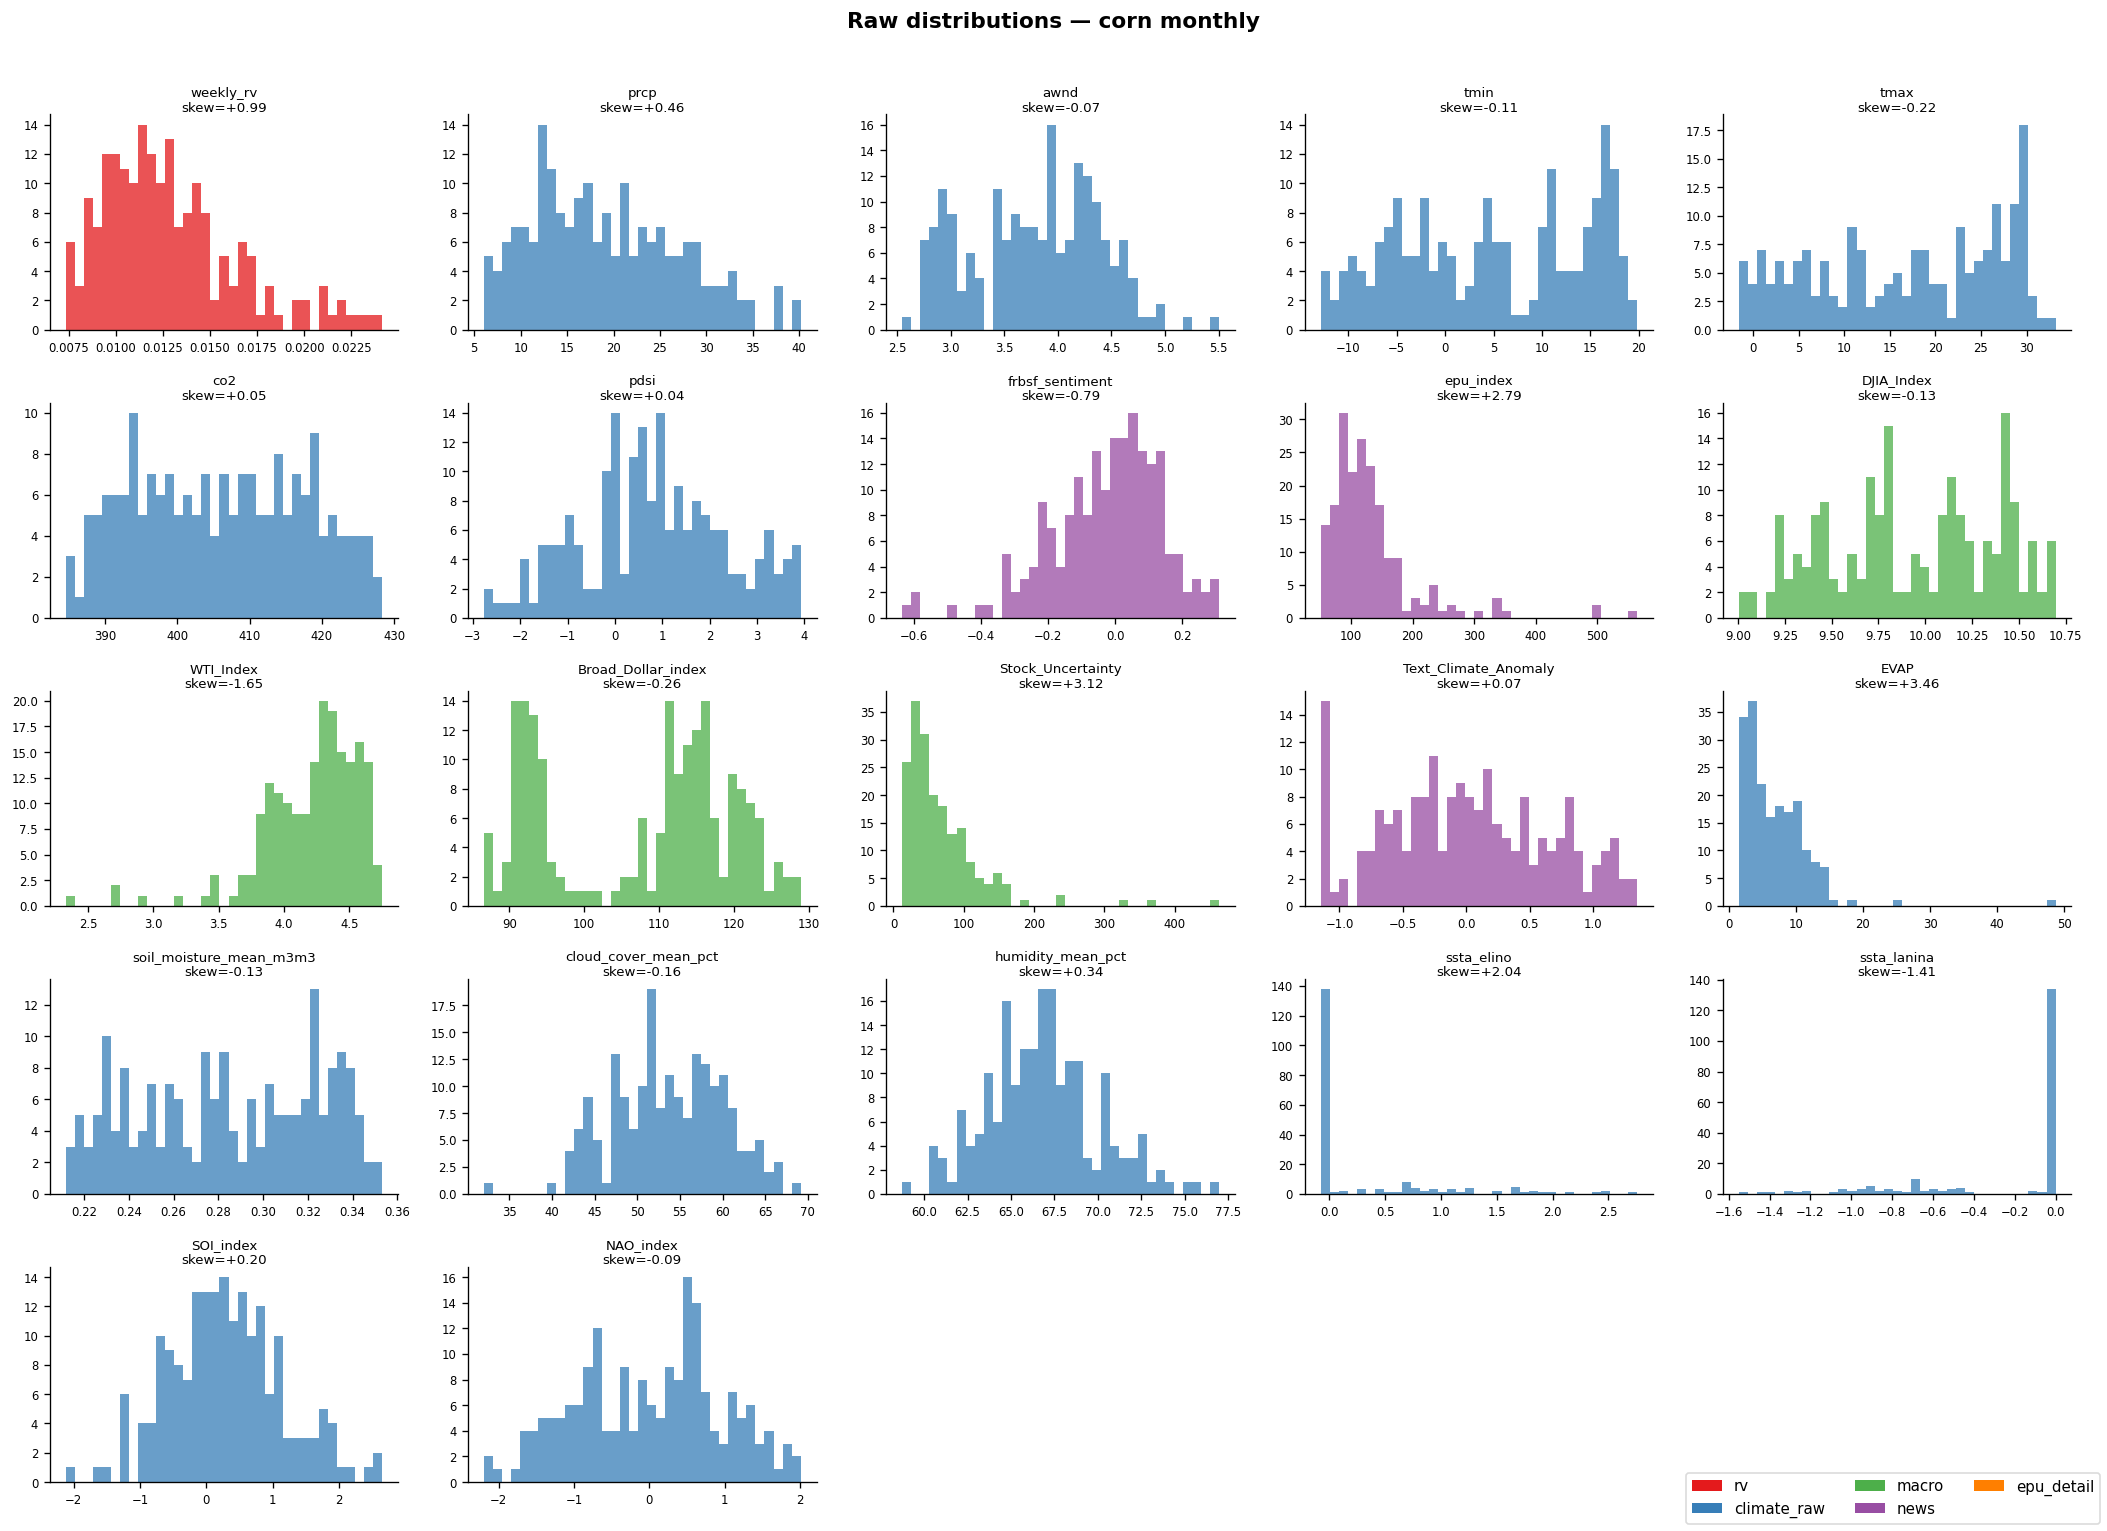

In [8]:
# ── Histograms: all features coloured by group ────────────────────────────────
ncols = 5
nrows = int(np.ceil(len(FEATURE_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.5))
axes = axes.ravel()

for idx, col in enumerate(FEATURE_COLS):
    ax = axes[idx]
    color = GROUP_COLORS.get(group_of(col), '#888')
    s = df_clean[col].values
    ax.hist(s, bins=35, color=color, alpha=0.75, edgecolor='none')
    sk = stats.skew(s)
    ax.set_title(f'{col}\nskew={sk:+.2f}', fontsize=8, pad=2)
    ax.tick_params(labelsize=7)
    ax.set_ylabel('')
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)

for ax in axes[len(FEATURE_COLS):]:
    ax.set_visible(False)

# Legend
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=handles, loc='lower right', ncol=3, fontsize=9, framealpha=0.7)
fig.suptitle(f'Raw distributions — {CROP} {FREQUENCY}', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Time Series Plots & Trend Detection

Before removing trends, we visualise all features against time.
Key findings from this data:
- **CO₂**: strong upward trend (~9.5% total drift over the period)
- **DJIA_Index**: upward trend (~15% drift)
- **Broad_Dollar_index**: upward trend (~35% drift — largest)
- **tmin / tmax**: strong seasonal cycle (ACF at lag 26 ≈ −0.71)

Trends act as common drivers and introduce spurious links ("solar forcing" example in `tigramite_tutorial_assumptions.ipynb`). They must be removed.

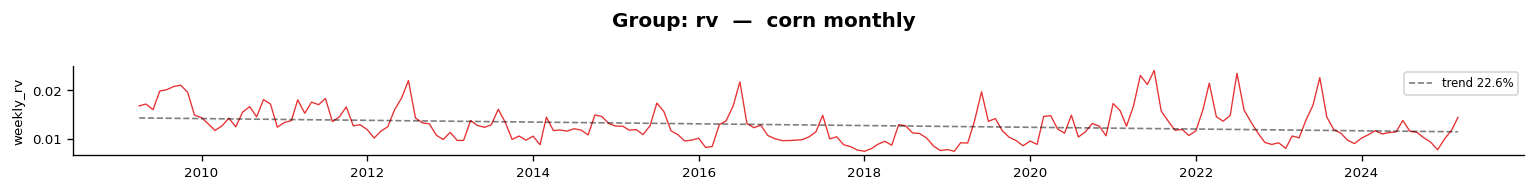

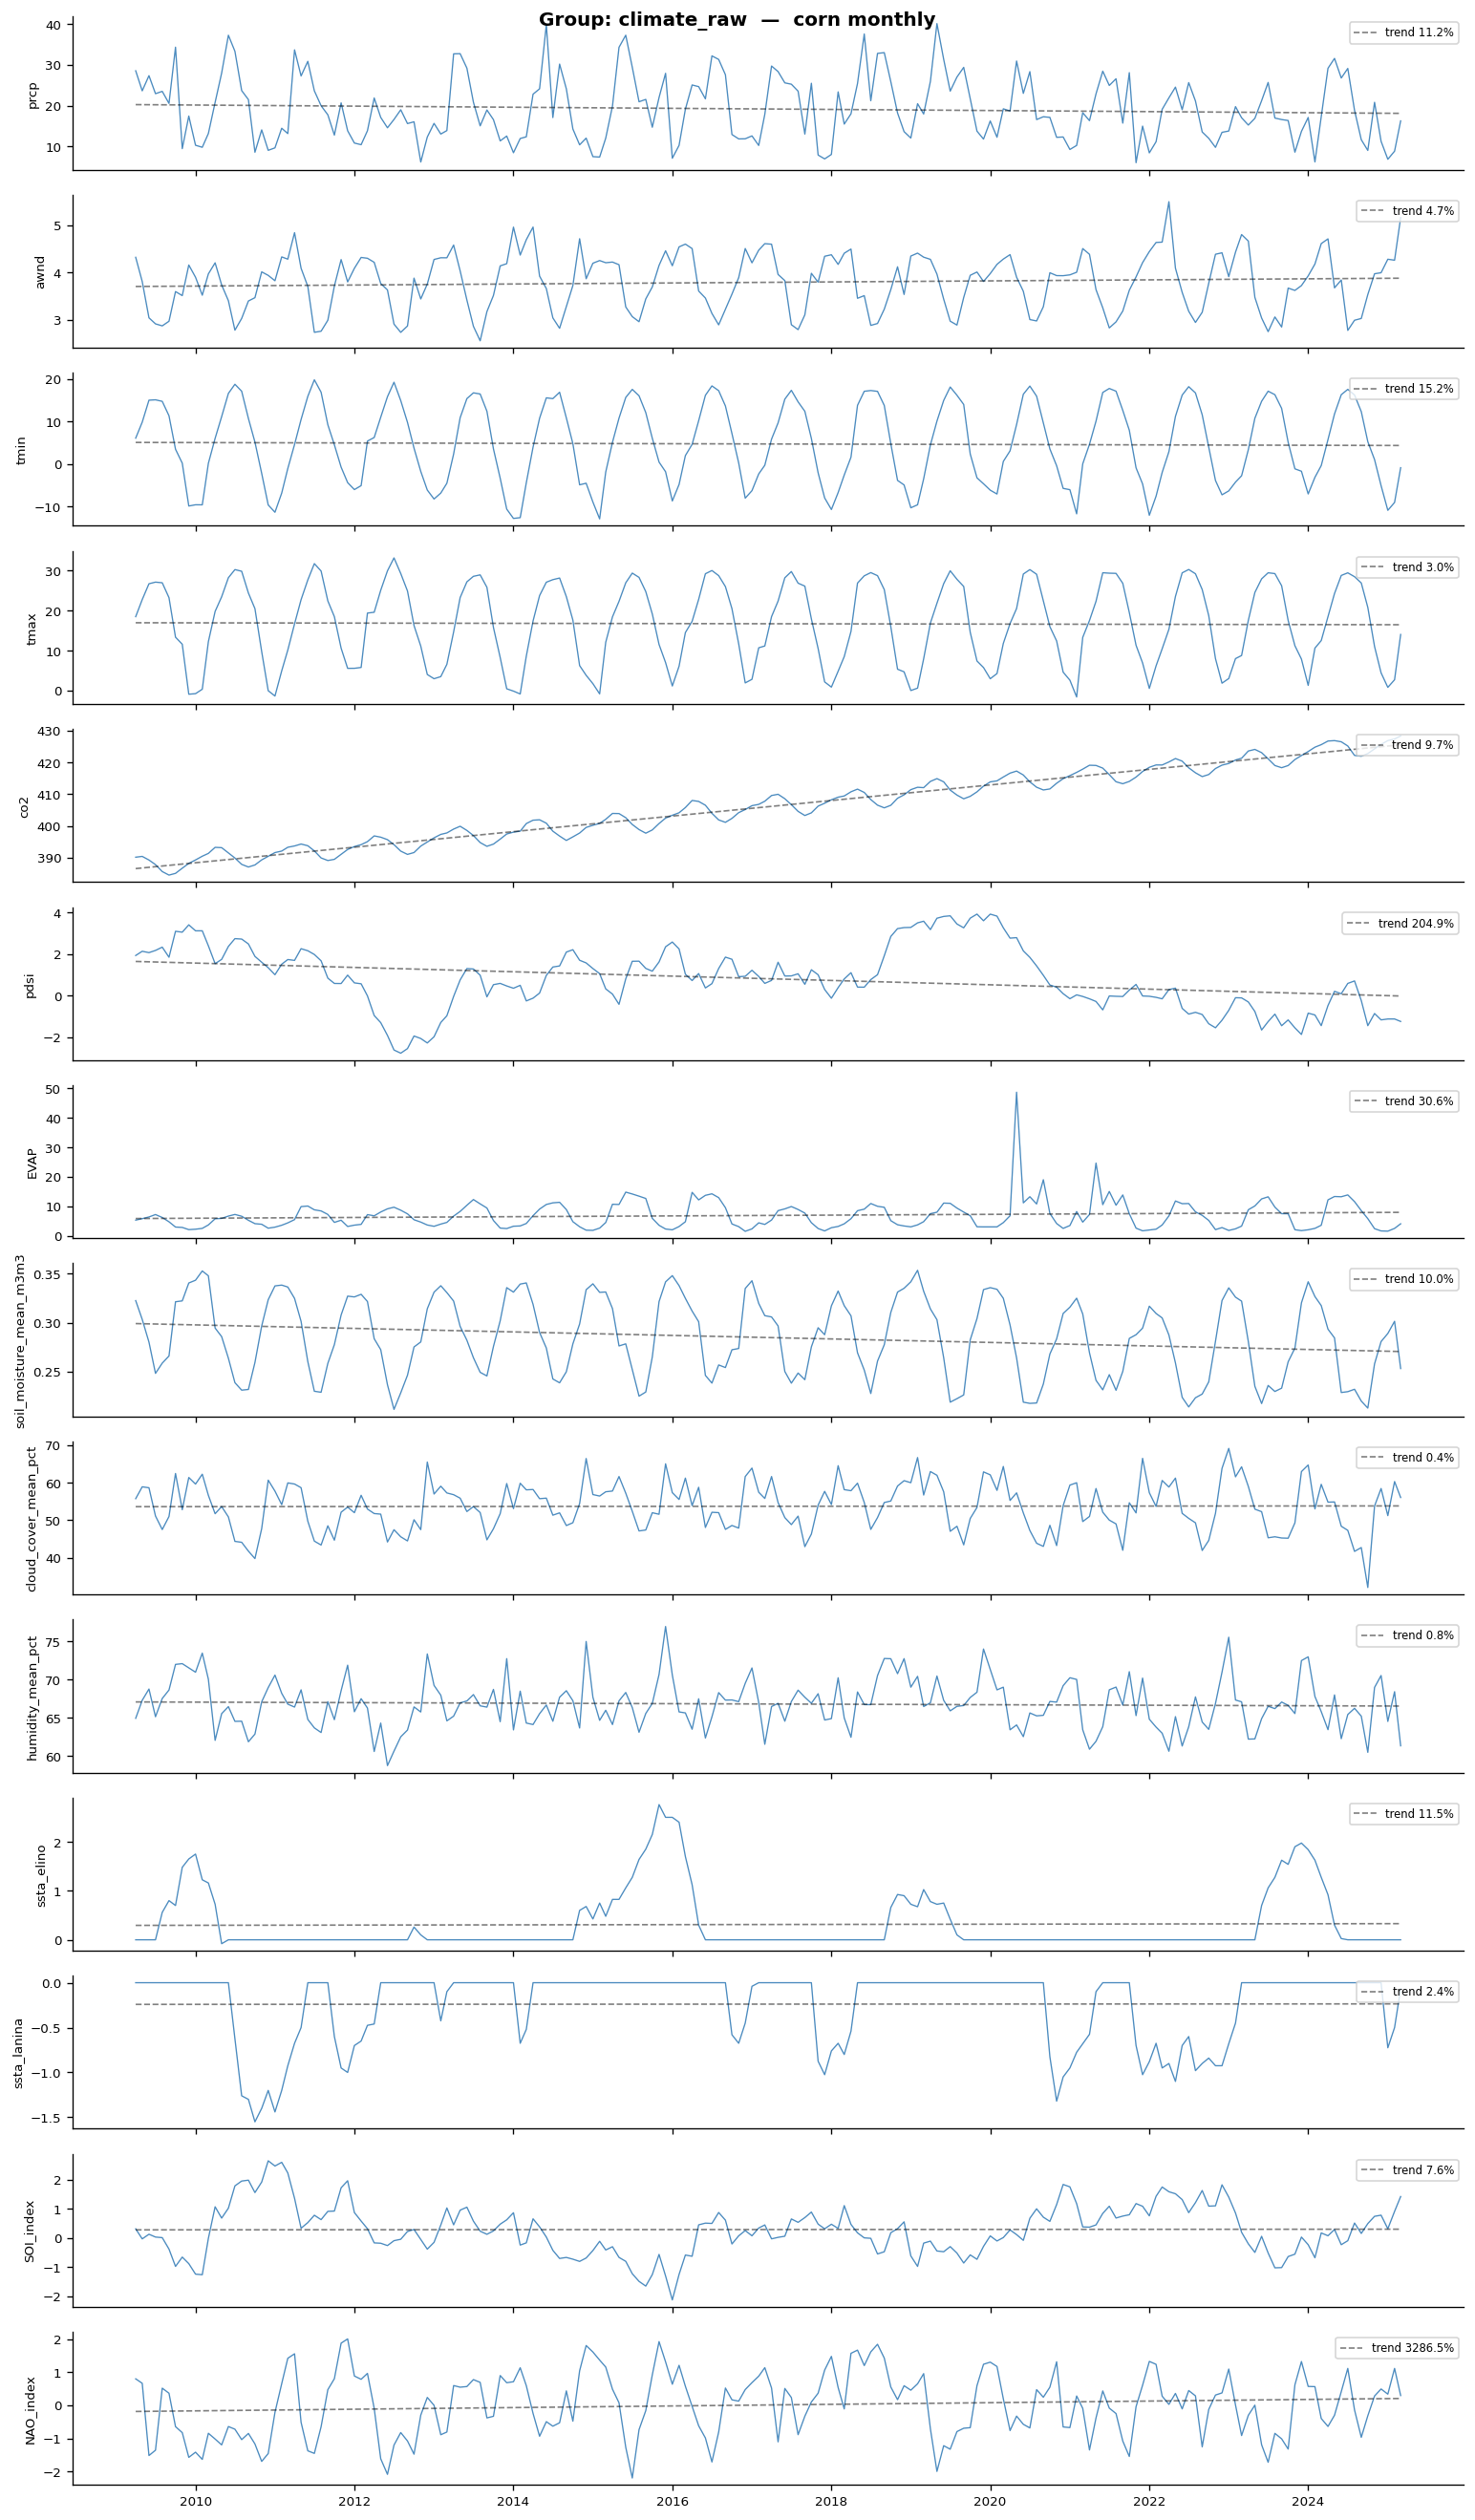

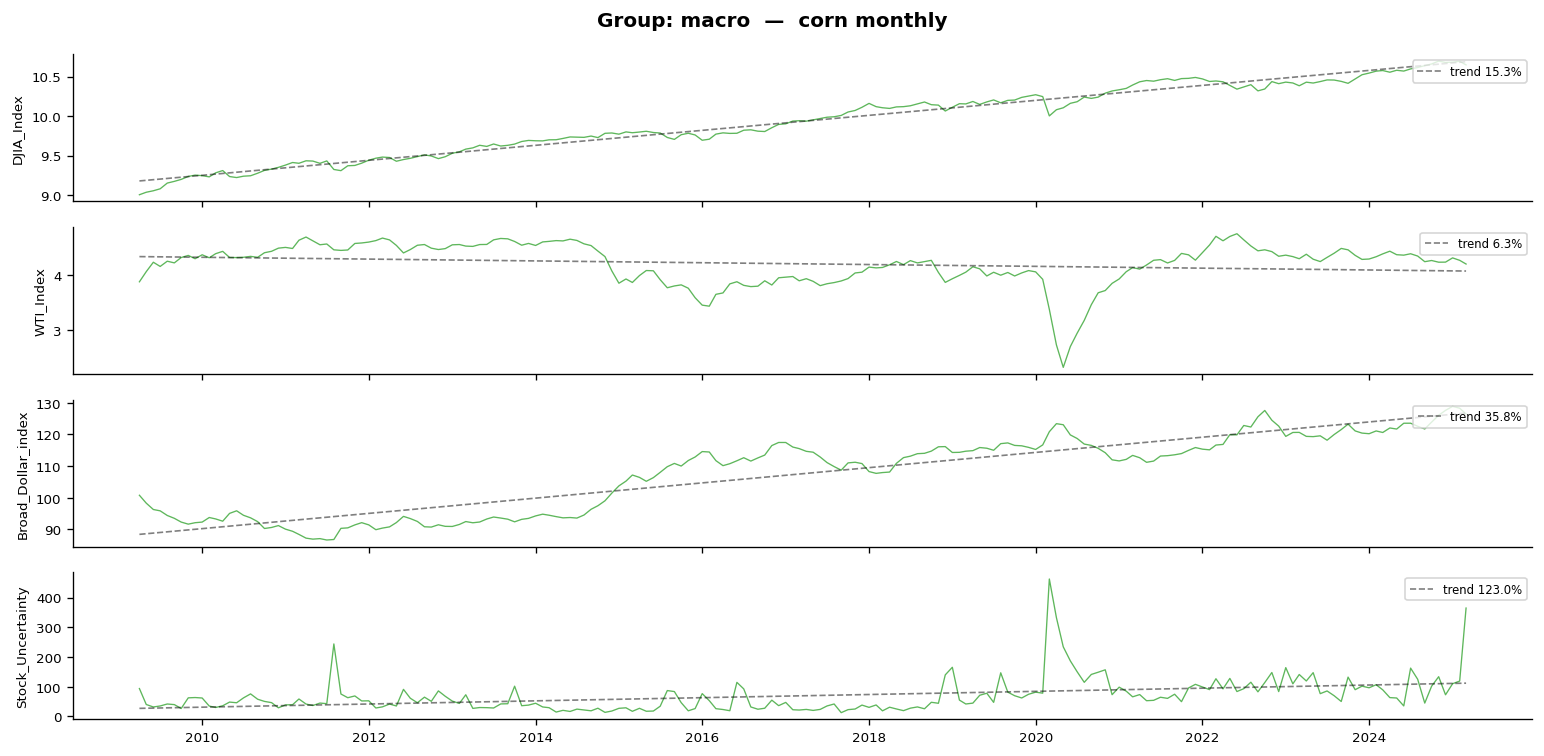

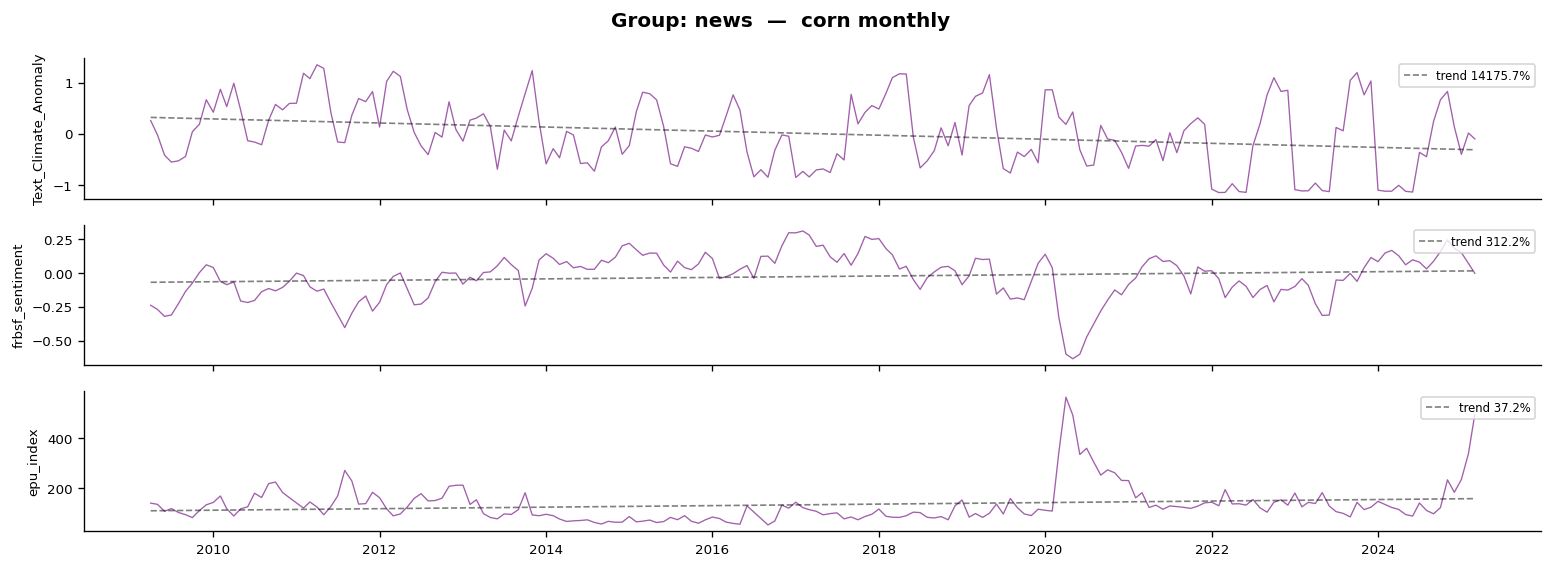

In [9]:
# ── Plot time series by group ─────────────────────────────────────────────────
for group_name, cols in FEATURE_GROUPS.items():
    cols_present = [c for c in cols if c in df_clean.columns]
    if not cols_present:
        continue
    n = len(cols_present)
    fig, axes = plt.subplots(n, 1, figsize=(13, n * 1.6), sharex=True)
    if n == 1:
        axes = [axes]
    color = GROUP_COLORS.get(group_name, '#888')
    for ax, col in zip(axes, cols_present):
        ax.plot(df_clean['date'], df_clean[col], lw=0.8, color=color, alpha=0.9)
        # Add trend line
        t = np.arange(len(df_clean))
        slope, intercept = np.polyfit(t, df_clean[col], 1)
        trend_pct = abs(slope * len(t) / df_clean[col].mean()) * 100
        ax.plot(df_clean['date'], slope*t + intercept, 'k--', lw=1.0,
                alpha=0.5, label=f'trend {trend_pct:.1f}%')
        ax.set_ylabel(col, fontsize=8)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=7, loc='upper right')
        for spine in ['top','right']:
            ax.spines[spine].set_visible(False)
    fig.suptitle(f'Group: {group_name}  —  {CROP} {FREQUENCY}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Seasonality Analysis

We check the seasonal autocorrelation structure to identify which variables need anomalization.

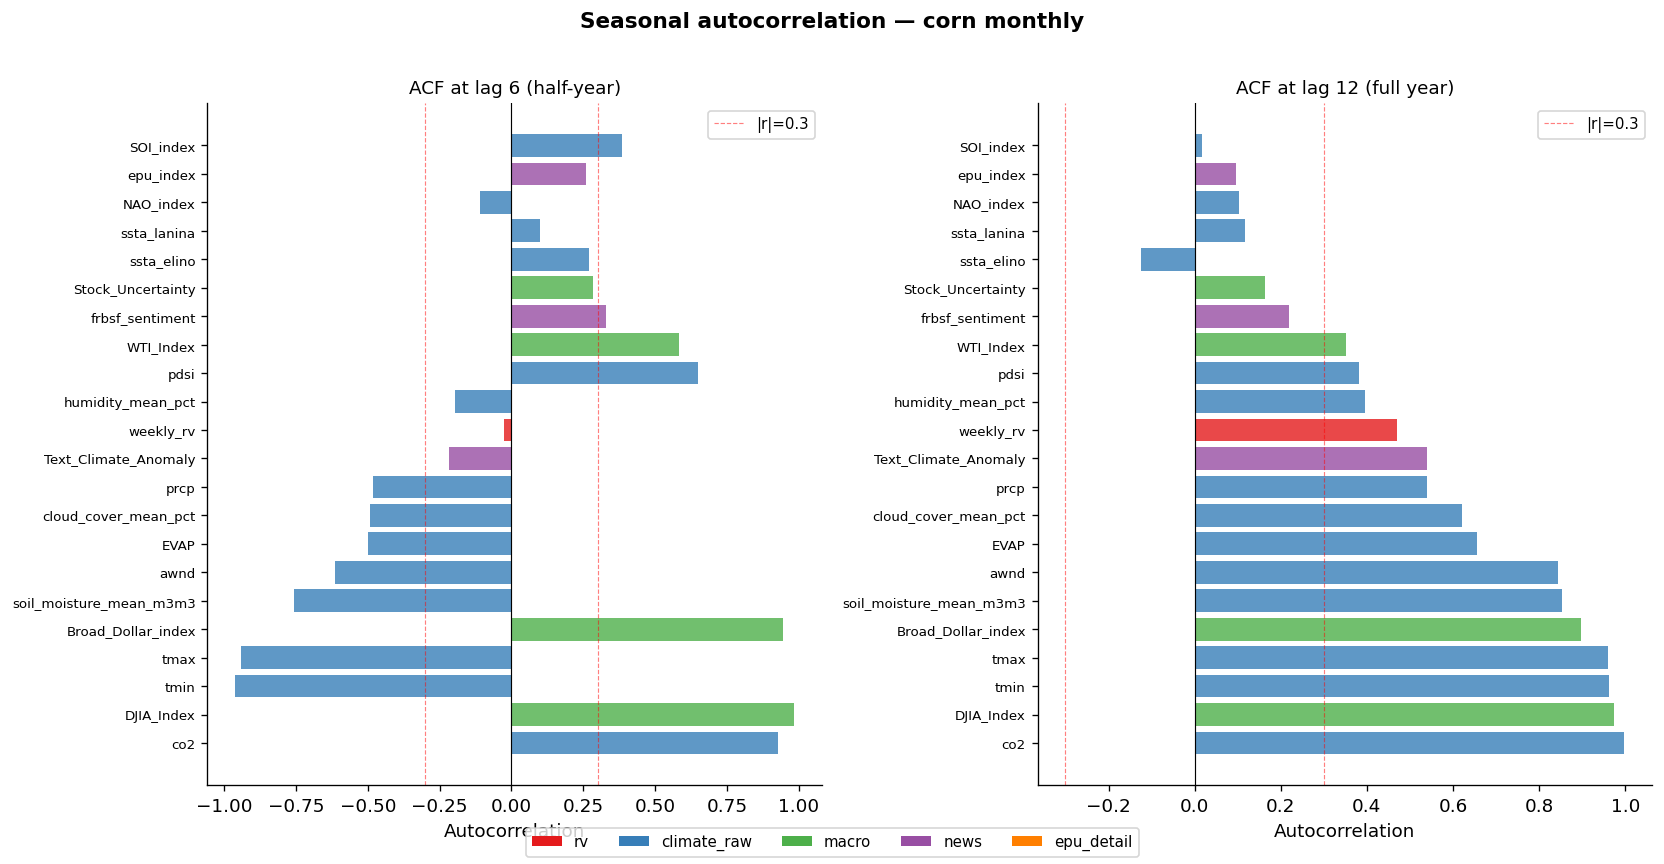

Variables with strong annual seasonality (|ACF|>0.15 at lag 12):
['weekly_rv', 'prcp', 'awnd', 'tmin', 'tmax', 'co2', 'pdsi', 'frbsf_sentiment', 'DJIA_Index', 'WTI_Index', 'Broad_Dollar_index', 'Stock_Uncertainty', 'Text_Climate_Anomaly', 'EVAP', 'soil_moisture_mean_m3m3', 'cloud_cover_mean_pct', 'humidity_mean_pct']


In [10]:
# ── ACF at half-year and full-year lags ───────────────────────────────────────
acf_rows = []
for c in FEATURE_COLS:
    s = pd.Series(df_clean[c].values)
    acf_half = s.autocorr(lag=CYCLE_LEN // 2)
    acf_year = s.autocorr(lag=CYCLE_LEN)
    acf_rows.append({'feature': c, 'ACF_half': acf_half, 'ACF_year': acf_year})

acf_df = pd.DataFrame(acf_rows).set_index('feature')

# Sort by absolute ACF at annual lag
acf_sorted = acf_df.reindex(acf_df['ACF_year'].abs().sort_values(ascending=False).index)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, col, label in zip(axes, ['ACF_half', 'ACF_year'],
                           [f'ACF at lag {CYCLE_LEN//2} (half-year)',
                            f'ACF at lag {CYCLE_LEN} (full year)']):
    colors = [GROUP_COLORS.get(group_of(c), '#888') for c in acf_sorted.index]
    ax.barh(acf_sorted.index, acf_sorted[col], color=colors, alpha=0.8)
    ax.axvline(0, color='k', lw=0.7)
    ax.axvline(0.3, color='r', lw=0.7, ls='--', alpha=0.5, label='|r|=0.3')
    ax.axvline(-0.3, color='r', lw=0.7, ls='--', alpha=0.5)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Autocorrelation')
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=9)
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)

handles = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=9)
fig.suptitle(f'Seasonal autocorrelation — {CROP} {FREQUENCY}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

seasonal_vars = acf_df[acf_df['ACF_year'].abs() > 0.15].index.tolist()
print(f'Variables with strong annual seasonality (|ACF|>0.15 at lag {CYCLE_LEN}):')
print(seasonal_vars)

## 5. Preprocessing Pipeline

Following the tigramite tutorial (`tigramite_tutorial_assumptions.ipynb` and the climate case study), the preprocessing pipeline is:

1. **Detrend** — remove long-term trend via Gaussian smoother (`pp.smooth`, 15-year width)
2. **Anomalize** — subtract the seasonal mean and divide by seasonal std per phase
3. **Gaussianise** — rank-based transform (`pp.trafo2normal`) to give normal marginals

Steps 1 and 2 address the *causal sufficiency violation* caused by common external drivers (warming trend, solar/seasonal forcing).  
Step 3 is needed because `ParCorr` assumes Gaussian noise — without it, our data fails the normality assumption for virtually every feature.

In [11]:
def anomalize(arr_2d, cycle_length):
    """Remove seasonal mean and divide by seasonal std, column-wise."""
    out = arr_2d.copy().astype(float)
    for phase in range(cycle_length):
        idx = slice(phase, None, cycle_length)
        out[idx] -= arr_2d[idx].mean(axis=0)
        std = arr_2d[idx].std(axis=0)
        std[std == 0] = 1.0
        out[idx] /= std
    return out


# ── Step 1: Detrend with 15-year Gaussian smoother ───────────────────────────
SMOOTH_WIDTH = 15 * CYCLE_LEN

arr = df_clean[FEATURE_COLS].values.astype(float)

arr_detrended = pp.smooth(
    arr,
    smooth_width=SMOOTH_WIDTH,
    kernel='gaussian',
    residuals=True,
)
print(f'Detrended: {arr_detrended.shape}')

# ── Step 2: Anomalize (remove seasonal cycle) ─────────────────────────────────
arr_anomalized = anomalize(arr_detrended, cycle_length=CYCLE_LEN)
print(f'Anomalized: {arr_anomalized.shape}')

# ── Step 3: Gaussianise ───────────────────────────────────────────────────────
arr_normal = pp.trafo2normal(arr_anomalized)
print(f'Gaussianised: {arr_normal.shape}')

Detrended: (192, 22)
Anomalized: (192, 22)
Gaussianised: (192, 22)


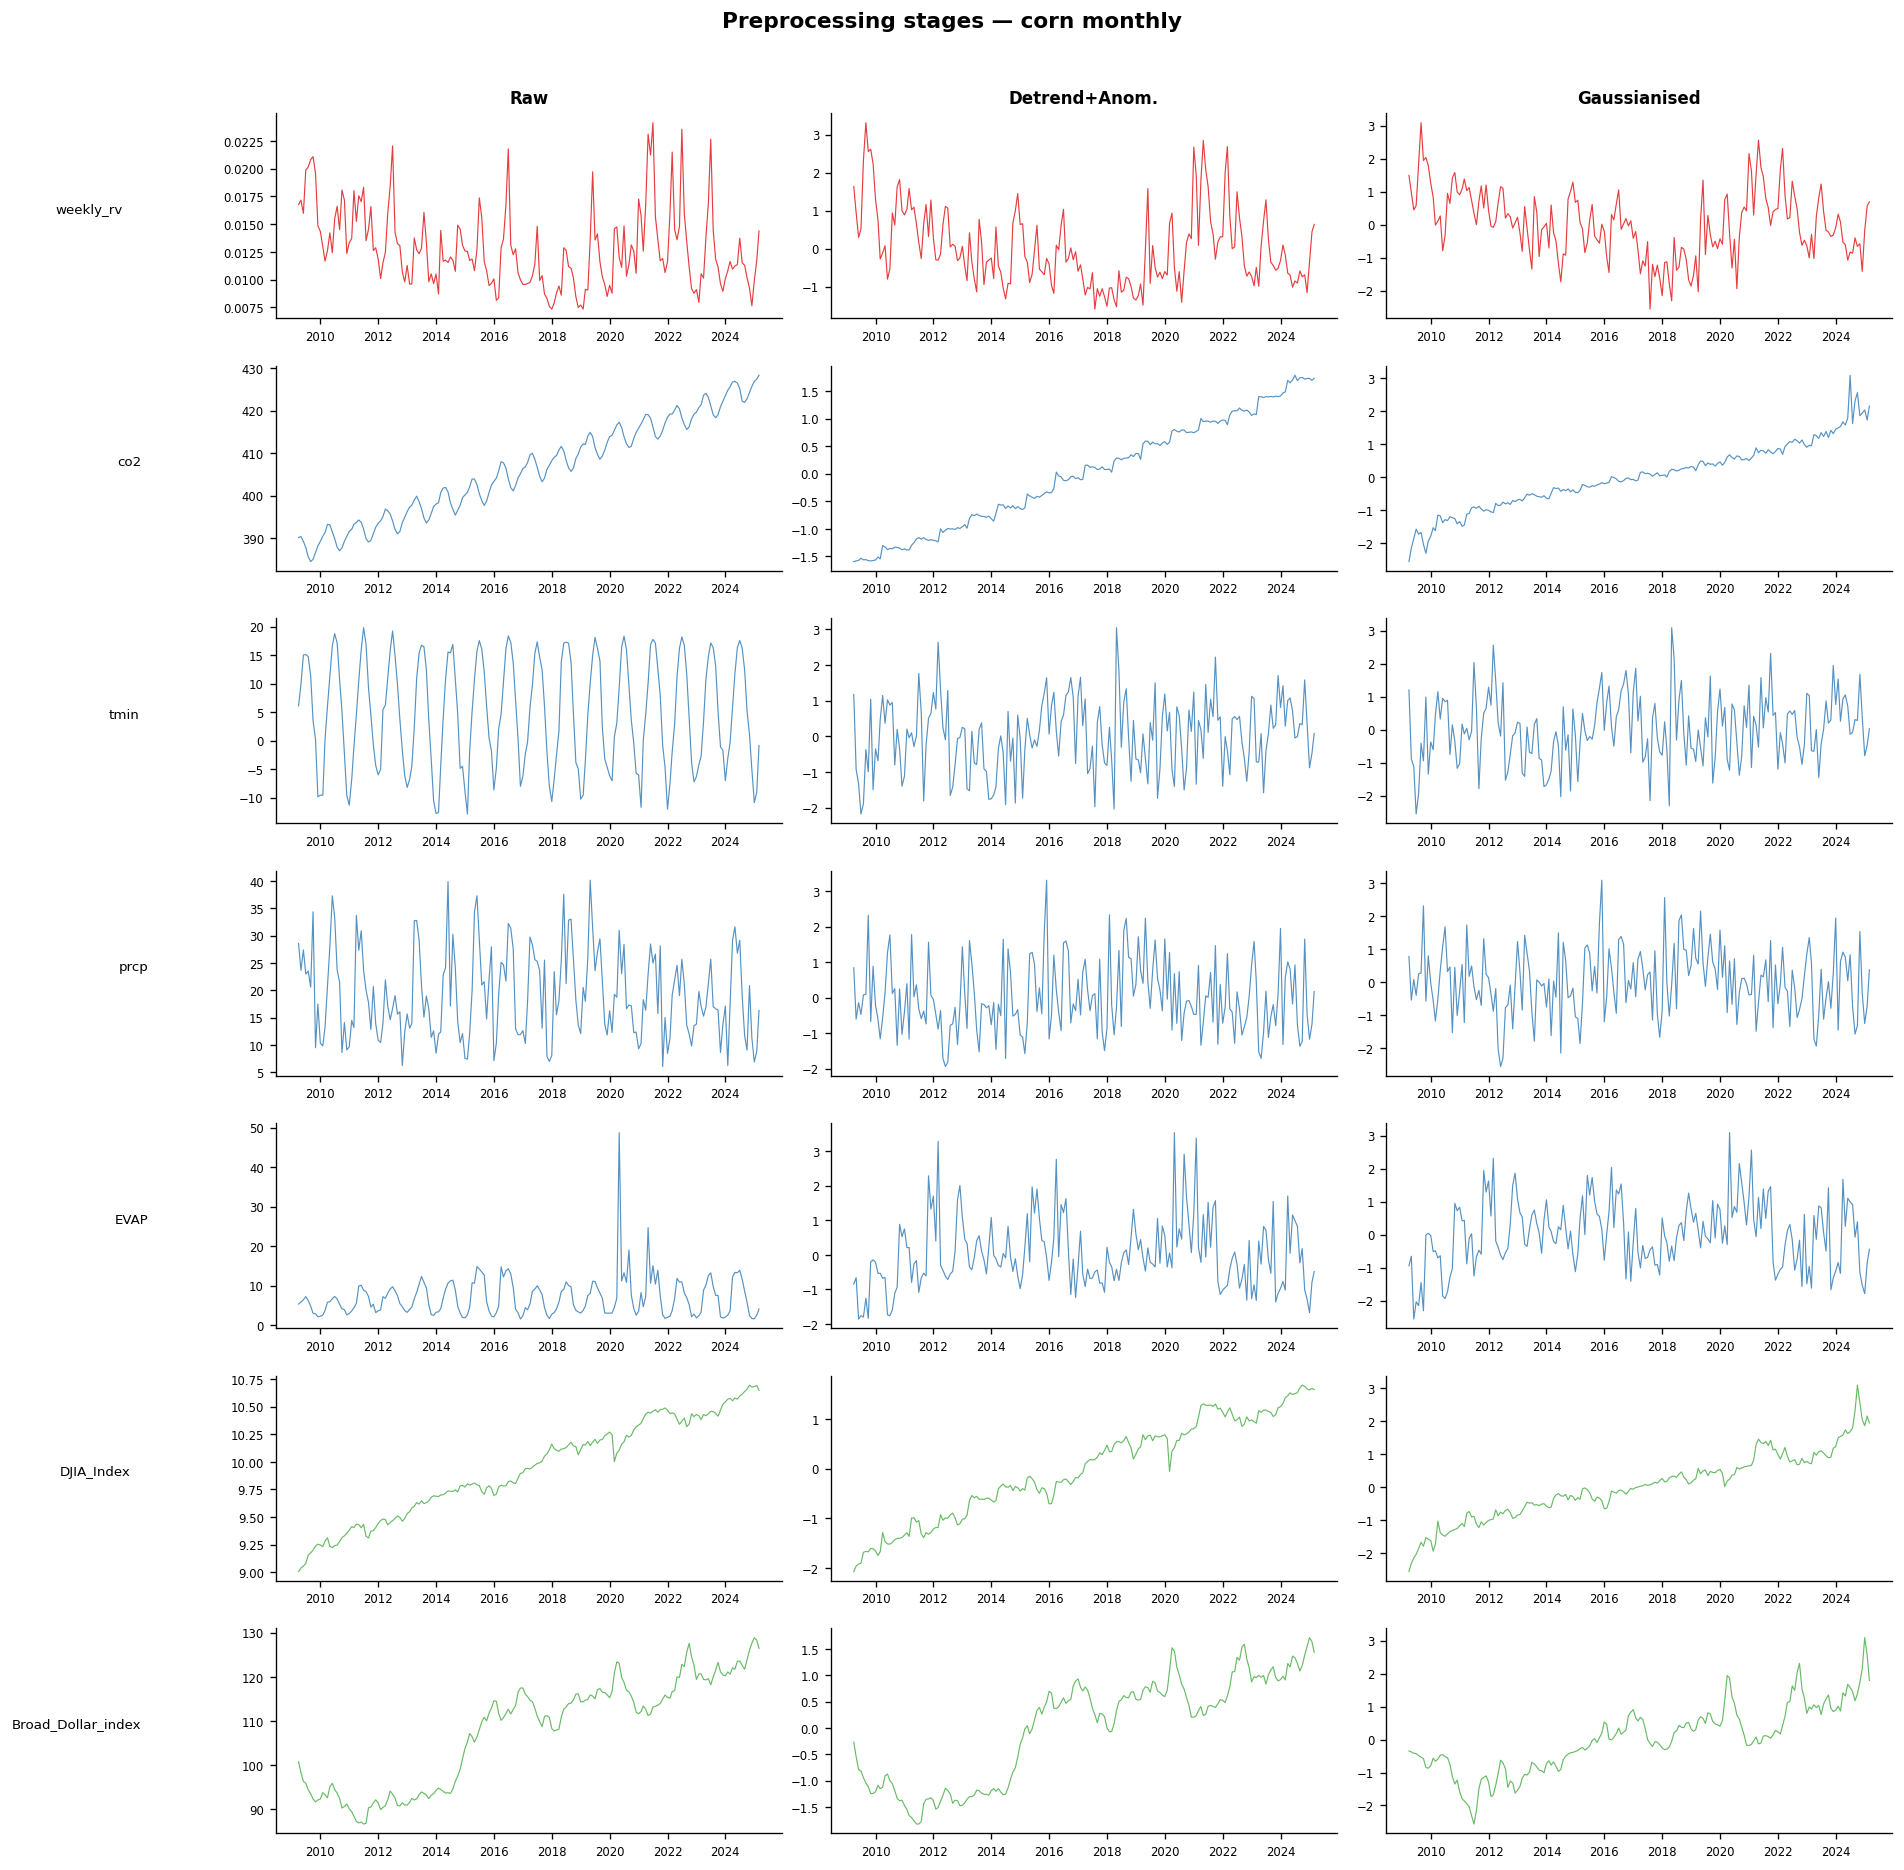

In [12]:
# ── Visualise preprocessing effect on selected features ───────────────────────
SHOW_COLS = ['weekly_rv', 'co2', 'tmin', 'prcp', 'epu_trade', 'EVAP',
             'DJIA_Index', 'Broad_Dollar_index']
SHOW_COLS = [c for c in SHOW_COLS if c in FEATURE_COLS]

n = len(SHOW_COLS)
fig, axes = plt.subplots(n, 3, figsize=(16, n * 2.2))

stages = [
    ('Raw',           arr,           df_clean['date']),
    ('Detrend+Anom.', arr_anomalized, df_clean['date']),
    ('Gaussianised',  arr_normal,     df_clean['date']),
]

for row, col in enumerate(SHOW_COLS):
    cidx = FEATURE_COLS.index(col)
    color = GROUP_COLORS.get(group_of(col), '#888')
    for col_ax, (stage_name, stage_arr, dates) in enumerate(stages):
        ax = axes[row, col_ax]
        ax.plot(dates, stage_arr[:, cidx], lw=0.7, color=color, alpha=0.85)
        if row == 0:
            ax.set_title(stage_name, fontsize=10, fontweight='bold')
        if col_ax == 0:
            ax.set_ylabel(col, fontsize=8, rotation=0, ha='right', labelpad=60)
        ax.tick_params(labelsize=7)
        for spine in ['top','right']:
            ax.spines[spine].set_visible(False)

fig.suptitle(f'Preprocessing stages — {CROP} {FREQUENCY}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

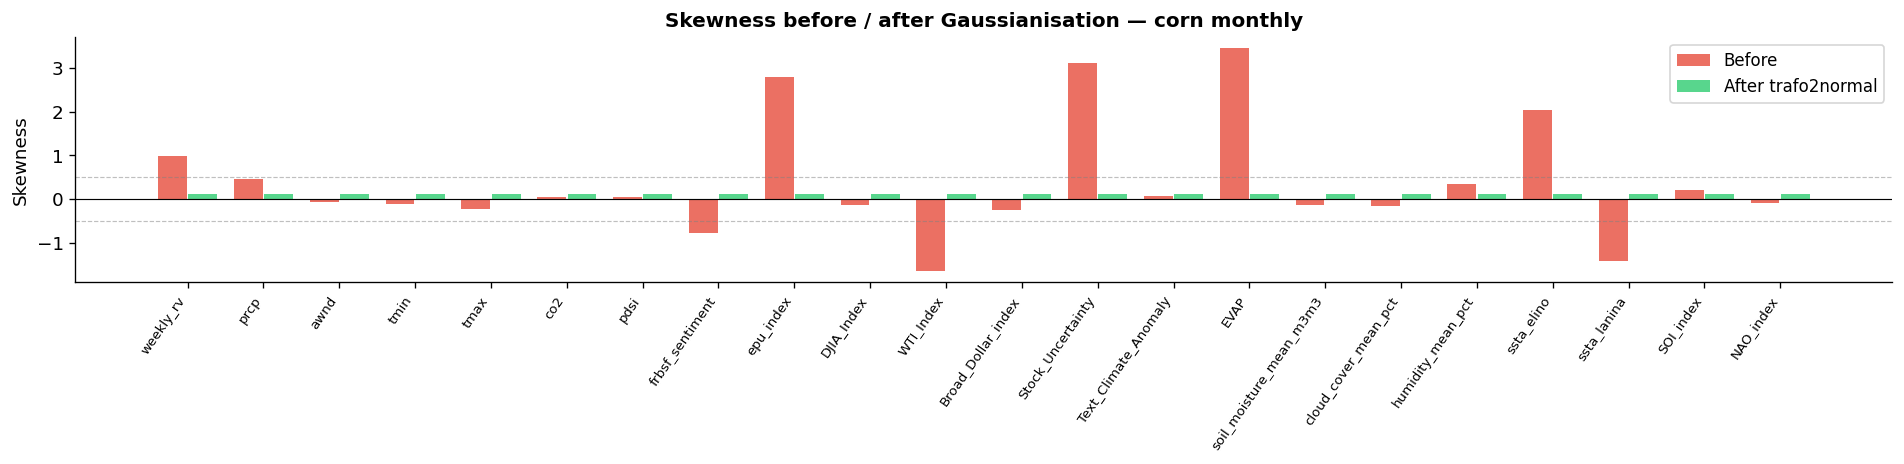

In [13]:
# ── Skewness before vs after Gaussianisation ──────────────────────────────────
skew_before = [stats.skew(arr[:, i]) for i in range(len(FEATURE_COLS))]
skew_after  = [stats.skew(arr_normal[:, i]) for i in range(len(FEATURE_COLS))]

x = np.arange(len(FEATURE_COLS))
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(x - 0.2, skew_before, width=0.38, label='Before', color='#e74c3c', alpha=0.8)
ax.bar(x + 0.2, skew_after,  width=0.38, label='After trafo2normal', color='#2ecc71', alpha=0.8)
ax.axhline(0, color='k', lw=0.7)
ax.axhline(0.5,  color='grey', lw=0.7, ls='--', alpha=0.5)
ax.axhline(-0.5, color='grey', lw=0.7, ls='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_COLS, rotation=55, ha='right', fontsize=8)
ax.set_ylabel('Skewness')
ax.set_title(f'Skewness before / after Gaussianisation — {CROP} {FREQUENCY}', fontweight='bold')
ax.legend(fontsize=10)
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Stationarity Check (Post-Preprocessing)

We use autocorrelation at the annual seasonal lag as a proxy for stationarity.  
After preprocessing, seasonal ACF should drop well below 0.15 for all variables.

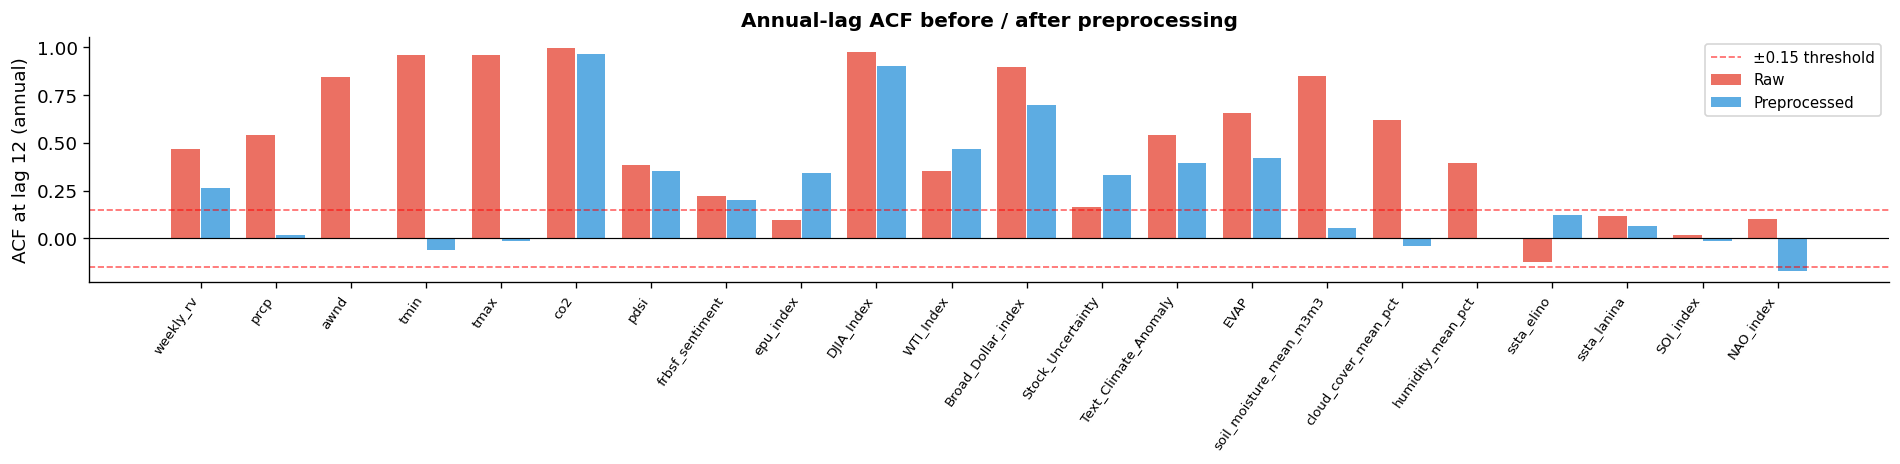

In [14]:
df_proc = pd.DataFrame(arr_normal, columns=FEATURE_COLS)

acf_raw_year  = [pd.Series(arr[:, i]).autocorr(lag=CYCLE_LEN) for i in range(len(FEATURE_COLS))]
acf_proc_year = [df_proc[c].autocorr(lag=CYCLE_LEN) for c in FEATURE_COLS]

fig, ax = plt.subplots(figsize=(16, 4))
x = np.arange(len(FEATURE_COLS))
ax.bar(x - 0.2, acf_raw_year,  width=0.38, label='Raw',        color='#e74c3c', alpha=0.8)
ax.bar(x + 0.2, acf_proc_year, width=0.38, label='Preprocessed', color='#3498db', alpha=0.8)
ax.axhline(0.15, color='red', ls='--', lw=1, alpha=0.6, label='±0.15 threshold')
ax.axhline(-0.15, color='red', ls='--', lw=1, alpha=0.6)
ax.axhline(0, color='k', lw=0.7)
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_COLS, rotation=55, ha='right', fontsize=8)
ax.set_ylabel(f'ACF at lag {CYCLE_LEN} (annual)')
ax.set_title('Annual-lag ACF before / after preprocessing', fontweight='bold')
ax.legend(fontsize=9)
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Build Tigramite DataFrame & Lagged Dependencies

We build the `tigramite.data_processing.DataFrame` on the preprocessed data and compute bivariate lagged conditional independence (`run_bivci`) to select `tau_max`.

From the tigramite tutorial: *"run_bivci at least conditions out some part of the autocorrelation"* — better than raw ACF for choosing `tau_max`.

In [15]:
# ── Build tigramite DataFrame ─────────────────────────────────────────────────
dataframe = pp.DataFrame(
    arr_normal,
    var_names=FEATURE_COLS,
    datatime={0: np.arange(len(arr_normal))},
)

parcorr = ParCorr(significance='analytic')
pcmci   = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=0)

print(f'Dataframe shape: T={dataframe.T}, N={dataframe.N}')
print(f'Variables: {FEATURE_COLS}')

Dataframe shape: T={0: 192}, N=22
Variables: ['weekly_rv', 'prcp', 'awnd', 'tmin', 'tmax', 'co2', 'pdsi', 'frbsf_sentiment', 'epu_index', 'DJIA_Index', 'WTI_Index', 'Broad_Dollar_index', 'Stock_Uncertainty', 'Text_Climate_Anomaly', 'EVAP', 'soil_moisture_mean_m3m3', 'cloud_cover_mean_pct', 'humidity_mean_pct', 'ssta_elino', 'ssta_lanina', 'SOI_index', 'NAO_index']


Computing bivariate lagged dependencies (tau_max=20)...


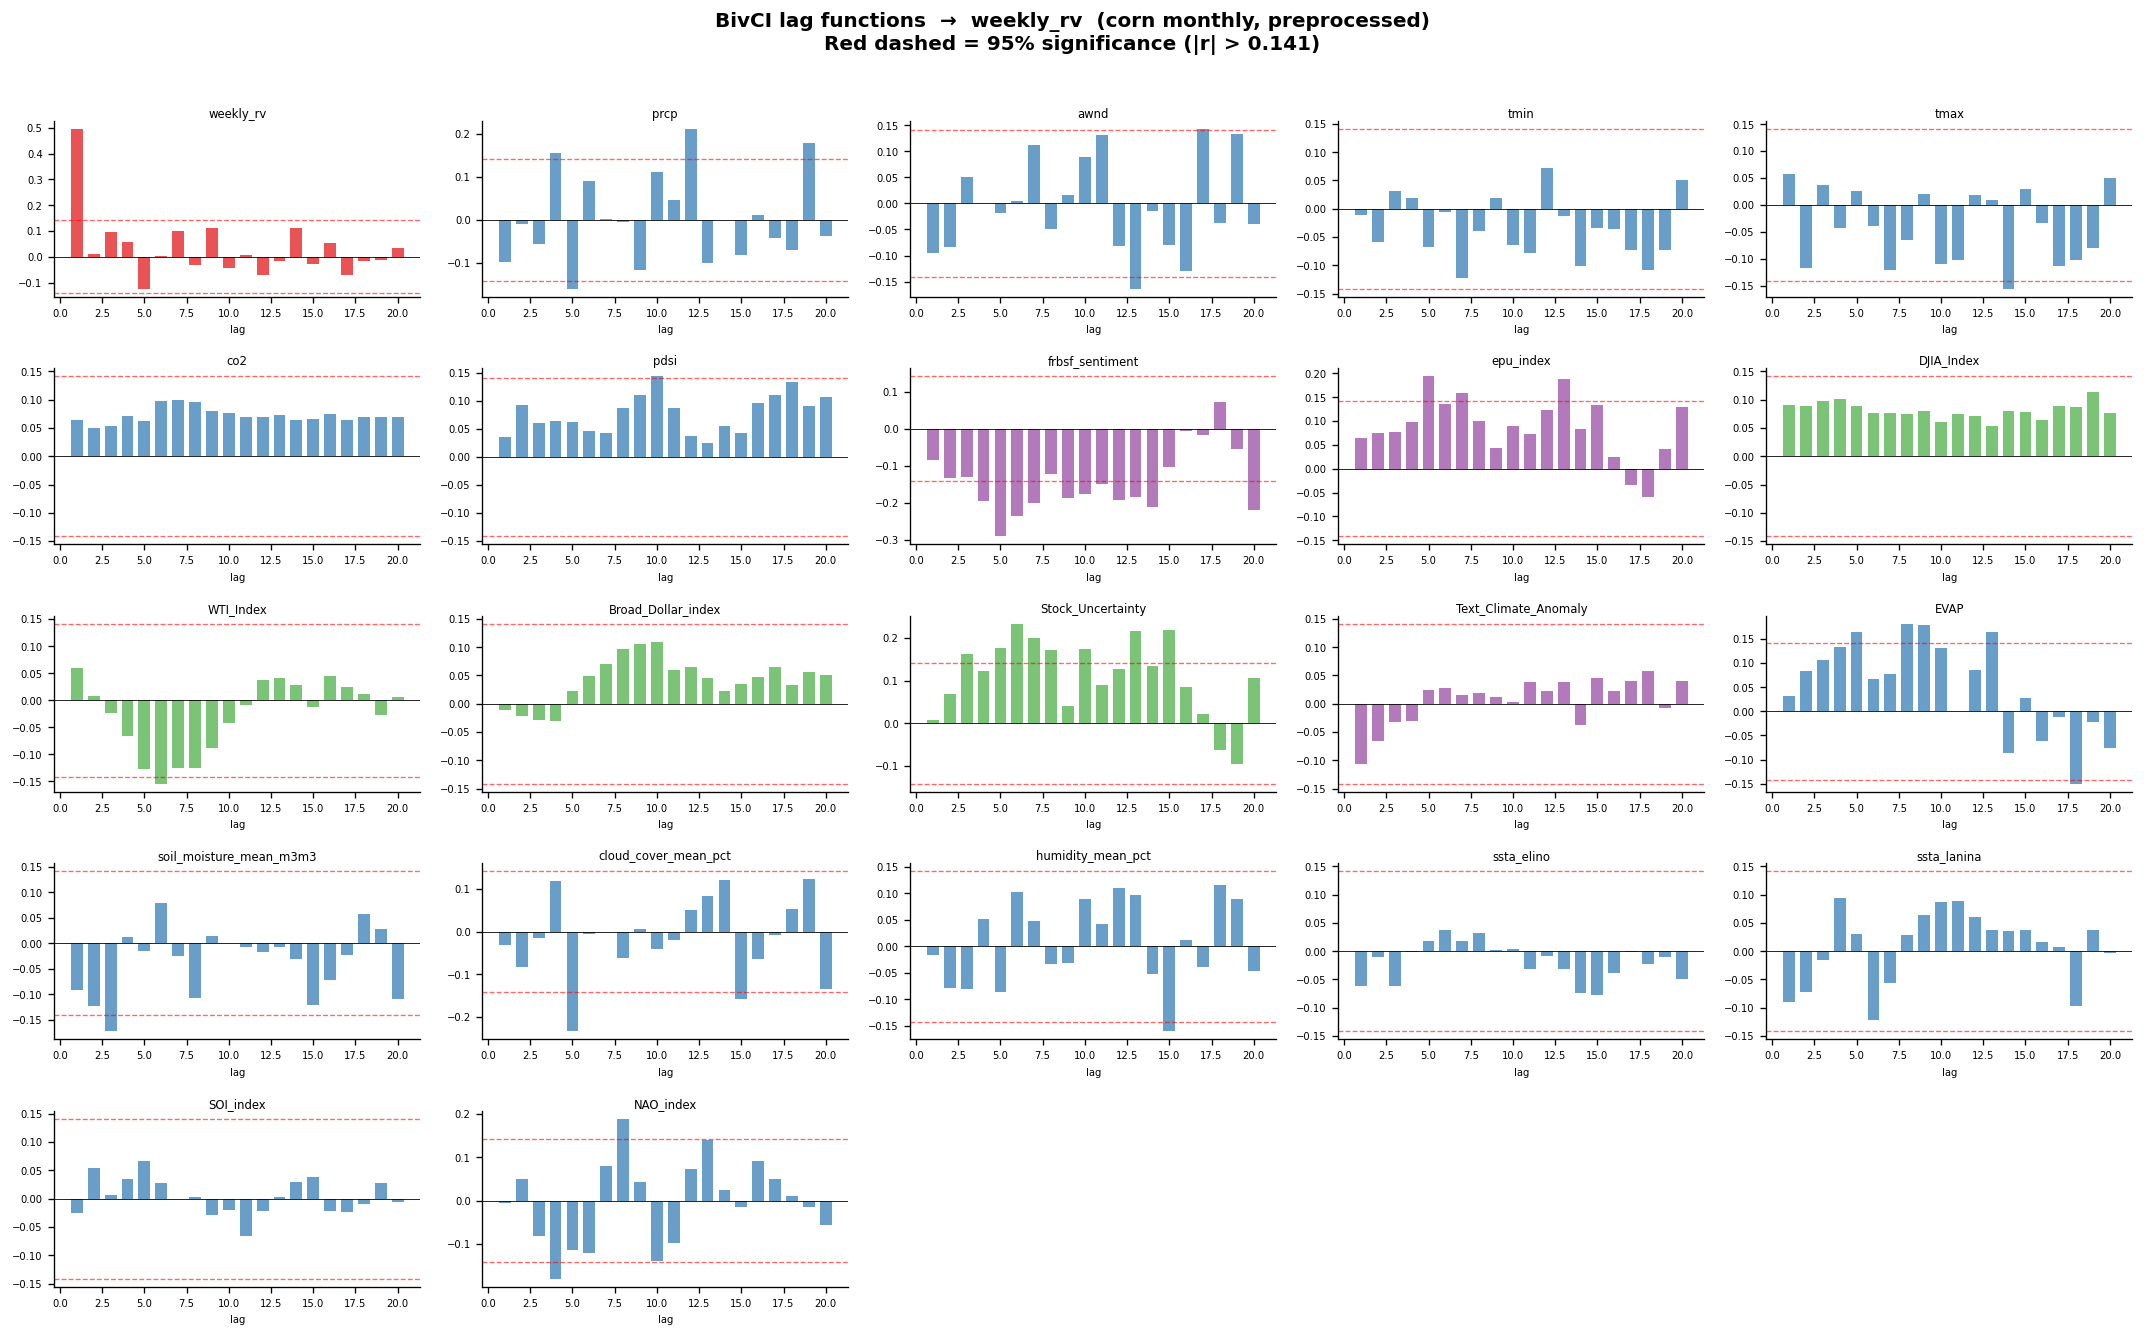

In [16]:
# ── Bivariate conditional independence lag functions (bivCI) ──────────────────
# More informative than raw correlations for choosing tau_max.
print('Computing bivariate lagged dependencies (tau_max=20)...')
bivci_vals = pcmci.run_bivci(tau_max=TAU_MAX_INSPECT, val_only=True)['val_matrix']

rv_idx = FEATURE_COLS.index('weekly_rv')

# Plot lag function matrix for RV vs all features
fig, axes = plt.subplots(
    int(np.ceil(len(FEATURE_COLS) / 5)), 5,
    figsize=(18, int(np.ceil(len(FEATURE_COLS) / 5)) * 2.2),
    sharey=False
)
axes = axes.ravel()
lags = np.arange(1, TAU_MAX_INSPECT + 1)

for idx, col in enumerate(FEATURE_COLS):
    ax = axes[idx]
    cidx = FEATURE_COLS.index(col)
    vals = bivci_vals[cidx, rv_idx, 1:TAU_MAX_INSPECT + 1]
    color = GROUP_COLORS.get(group_of(col), '#888')
    ax.bar(lags, vals, color=color, alpha=0.75, width=0.7)
    ax.axhline(0, color='k', lw=0.5)
    # 95% significance threshold for ParCorr (approx.)
    sig = 1.96 / np.sqrt(len(arr_normal))
    ax.axhline(sig,  color='r', ls='--', lw=0.8, alpha=0.6)
    ax.axhline(-sig, color='r', ls='--', lw=0.8, alpha=0.6)
    ax.set_title(col, fontsize=7, pad=2)
    ax.tick_params(labelsize=6)
    ax.set_xlabel('lag', fontsize=6)
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)

for ax in axes[len(FEATURE_COLS):]:
    ax.set_visible(False)

fig.suptitle(
    f'BivCI lag functions  →  weekly_rv  ({CROP} {FREQUENCY}, preprocessed)\n'
    f'Red dashed = 95% significance (|r| > {sig:.3f})',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

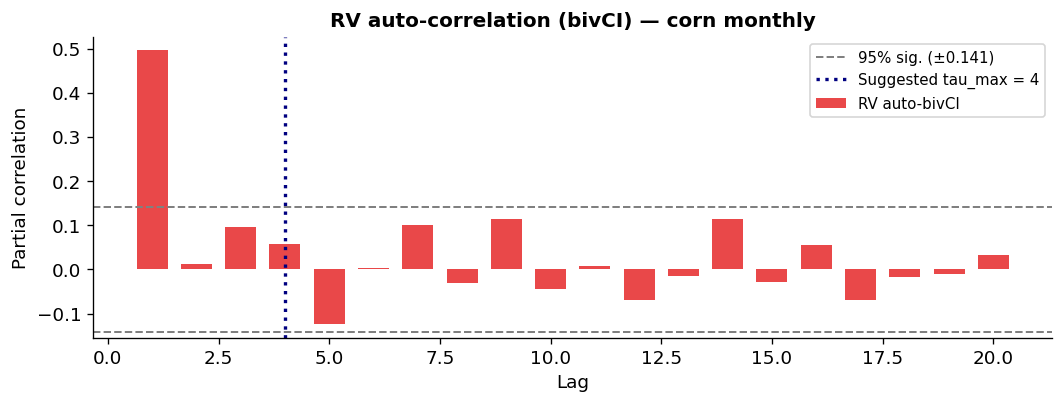


>>> Suggested tau_max = 4 (monthly steps)
    = ~0.3 years


In [17]:
# ── tau_max selection ─────────────────────────────────────────────────────────
# Plot RV auto-bivCI and find where it drops below significance
rv_auto = bivci_vals[rv_idx, rv_idx, 1:TAU_MAX_INSPECT + 1]
sig = 1.96 / np.sqrt(len(arr_normal))

first_insig = next((t+1 for t, v in enumerate(rv_auto) if abs(v) < sig), TAU_MAX_INSPECT)
suggested_tau_max = min(first_insig + 2, TAU_MAX_INSPECT)  # small buffer

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(lags, rv_auto, color='#e41a1c', alpha=0.8, width=0.7, label='RV auto-bivCI')
ax.axhline(sig,  color='grey', ls='--', lw=1.2, label=f'95% sig. (±{sig:.3f})')
ax.axhline(-sig, color='grey', ls='--', lw=1.2)
ax.axvline(suggested_tau_max, color='navy', ls=':', lw=2,
           label=f'Suggested tau_max = {suggested_tau_max}')
ax.set_xlabel('Lag')
ax.set_ylabel('Partial correlation')
ax.set_title(f'RV auto-correlation (bivCI) — {CROP} {FREQUENCY}', fontweight='bold')
ax.legend(fontsize=9)
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f'\n>>> Suggested tau_max = {suggested_tau_max} ({FREQUENCY} steps)')
if FREQUENCY == 'weekly':
    print(f'    = ~{suggested_tau_max/52:.1f} years')
else:
    print(f'    = ~{suggested_tau_max/12:.1f} years')

## 8. Scatter & Density Plots — CI Test Selection

As recommended in `tigramite_tutorial_conditional_independence_tests.ipynb`, we use scatter and density plots to assess the type of dependence:

| Pattern seen | CI test to use |
|---|---|
| Linear joint density, Gaussian marginals | `ParCorr` (fastest, highest power for linear) |
| Nonlinear but additive patterns | `GPDCtorch` (GP regression + distance correlation) |
| Nonlinear, non-additive, or multiplicative noise | `FAISSCMI` (kNN CMI, most general) |

We plot the top 8 cross-correlates of RV at their peak lag.

In [18]:
# ── Identify top 8 correlates of RV ──────────────────────────────────────────
peak_corr = {}
for col in FEATURE_COLS:
    if col == 'weekly_rv':
        continue
    cidx = FEATURE_COLS.index(col)
    cross = bivci_vals[cidx, rv_idx, 1:TAU_MAX_INSPECT + 1]
    max_lag = int(np.argmax(np.abs(cross))) + 1
    peak_corr[col] = (max_lag, cross[max_lag - 1])

top8 = sorted(peak_corr.items(), key=lambda x: abs(x[1][1]), reverse=True)[:8]
print('Top 8 correlates of weekly_rv:')
for feat, (lag, r) in top8:
    print(f'  {feat:35s}: peak lag={lag:2d}, bivCI={r:+.3f}')

Top 8 correlates of weekly_rv:
  frbsf_sentiment                    : peak lag= 5, bivCI=-0.290
  Stock_Uncertainty                  : peak lag= 6, bivCI=+0.234
  cloud_cover_mean_pct               : peak lag= 5, bivCI=-0.233
  prcp                               : peak lag=12, bivCI=+0.211
  epu_index                          : peak lag= 5, bivCI=+0.194
  NAO_index                          : peak lag= 8, bivCI=+0.189
  EVAP                               : peak lag= 8, bivCI=+0.182
  soil_moisture_mean_m3m3            : peak lag= 3, bivCI=-0.172


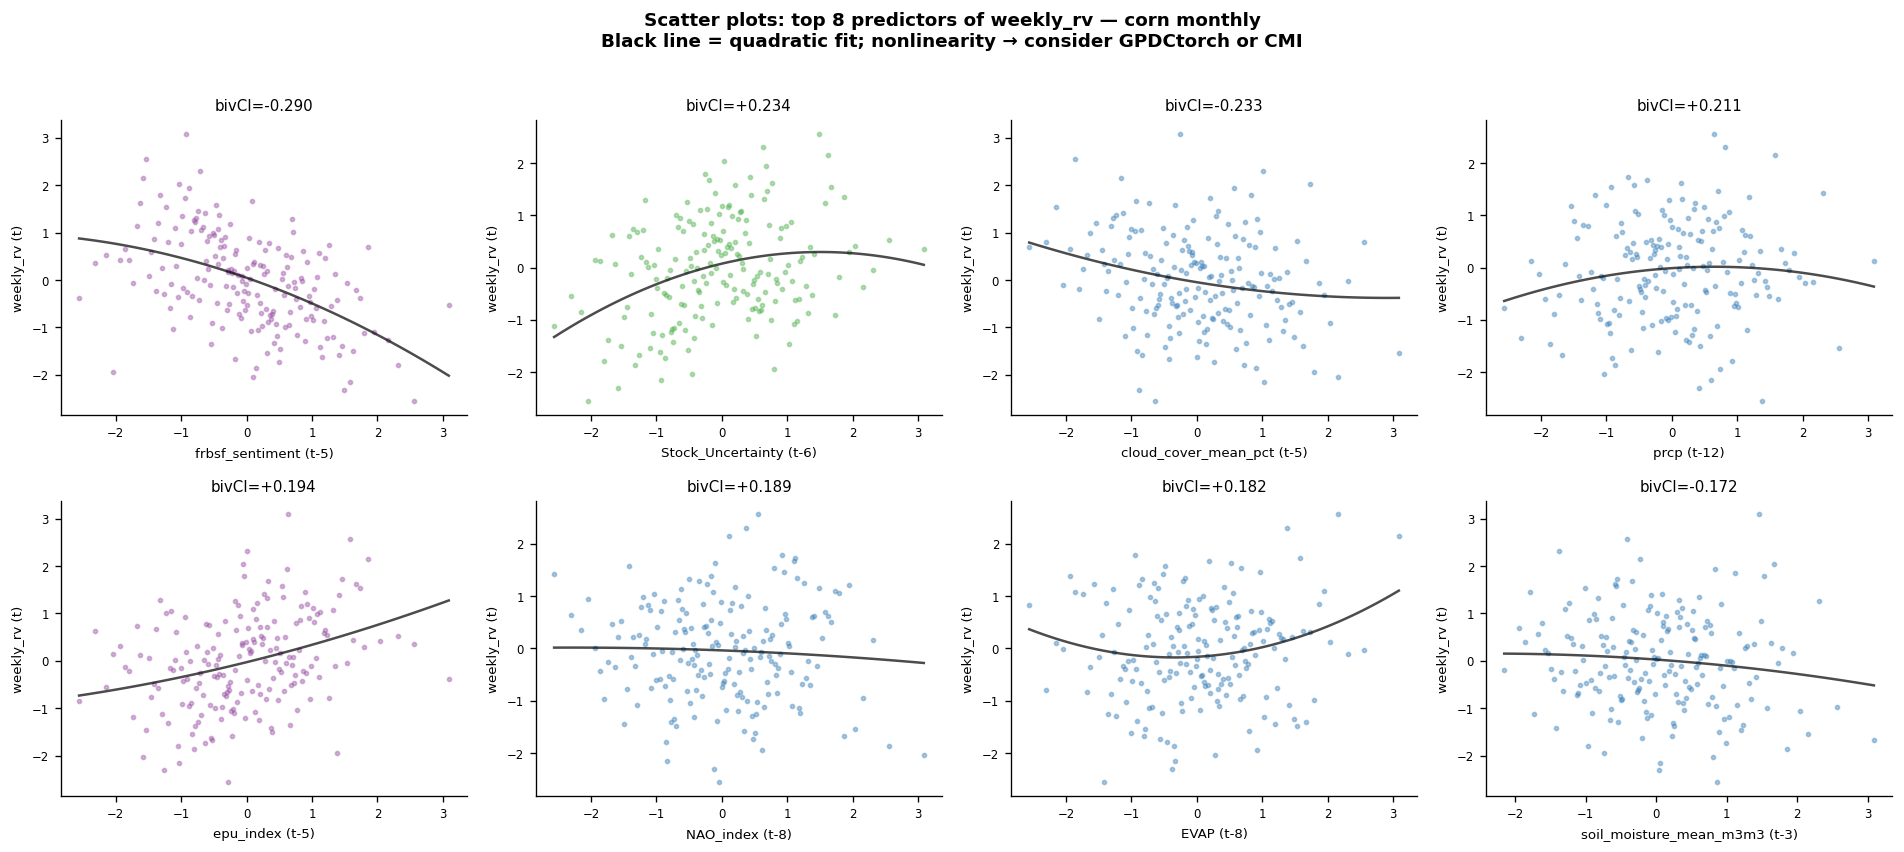

In [19]:
# ── Scatter plots: X_{t-lag} vs RV_t ─────────────────────────────────────────
nrow, ncol = 2, 4
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 4, nrow * 3.5))
axes = axes.ravel()

T = len(arr_normal)
rv_series = arr_normal[:, rv_idx]

for ax_idx, (feat, (lag, r)) in enumerate(top8):
    ax = axes[ax_idx]
    fidx = FEATURE_COLS.index(feat)
    x_lag = arr_normal[:T - lag, fidx]
    y_rv  = rv_series[lag:]
    color = GROUP_COLORS.get(group_of(feat), '#888')
    ax.scatter(x_lag, y_rv, s=6, alpha=0.4, color=color, rasterized=True)
    # Lowess-style trend via polynomial
    sort_idx = np.argsort(x_lag)
    z = np.polyfit(x_lag, y_rv, 2)
    p = np.poly1d(z)
    xs = np.linspace(x_lag.min(), x_lag.max(), 100)
    ax.plot(xs, p(xs), 'k-', lw=1.5, alpha=0.7)
    ax.set_xlabel(f'{feat} (t-{lag})', fontsize=8)
    ax.set_ylabel('weekly_rv (t)', fontsize=8)
    ax.set_title(f'bivCI={r:+.3f}', fontsize=9)
    ax.tick_params(labelsize=7)
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)

fig.suptitle(f'Scatter plots: top 8 predictors of weekly_rv — {CROP} {FREQUENCY}\n'
             'Black line = quadratic fit; nonlinearity → consider GPDCtorch or CMI',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. CI Test Selection Decision

Based on the scatter and density plots above, we assess which tests are appropriate.

In [20]:
# ── Quantify nonlinearity: R²_linear vs R²_quadratic ─────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

nonlin_rows = []
for feat, (lag, r) in top8:
    fidx = FEATURE_COLS.index(feat)
    X = arr_normal[:T - lag, fidx].reshape(-1, 1)
    y = rv_series[lag:]

    lin_r2  = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2').mean()
    quad_r2 = cross_val_score(
        Pipeline([('poly', PolynomialFeatures(degree=2)), ('lr', LinearRegression())]),
        X, y, cv=5, scoring='r2'
    ).mean()

    nonlin_rows.append({
        'feature': feat, 'lag': lag, 'bivCI': r,
        'R2_linear': lin_r2, 'R2_quadratic': quad_r2,
        'nonlin_gain': quad_r2 - lin_r2,
    })

nonlin_df = pd.DataFrame(nonlin_rows).set_index('feature')
print(nonlin_df[['lag','bivCI','R2_linear','R2_quadratic','nonlin_gain']].to_string(float_format='{:.3f}'.format))

                         lag  bivCI  R2_linear  R2_quadratic  nonlin_gain
feature                                                                  
frbsf_sentiment            5 -0.290     -0.290        -0.274        0.017
Stock_Uncertainty          6  0.234     -0.756        -0.821       -0.065
cloud_cover_mean_pct       5 -0.233     -0.734        -0.761       -0.027
prcp                      12  0.211     -0.641        -0.619        0.021
epu_index                  5  0.194     -0.570        -0.661       -0.091
NAO_index                  8  0.189     -0.775        -0.948       -0.173
EVAP                       8  0.182     -1.041        -0.939        0.102
soil_moisture_mean_m3m3    3 -0.172     -0.821        -0.832       -0.012


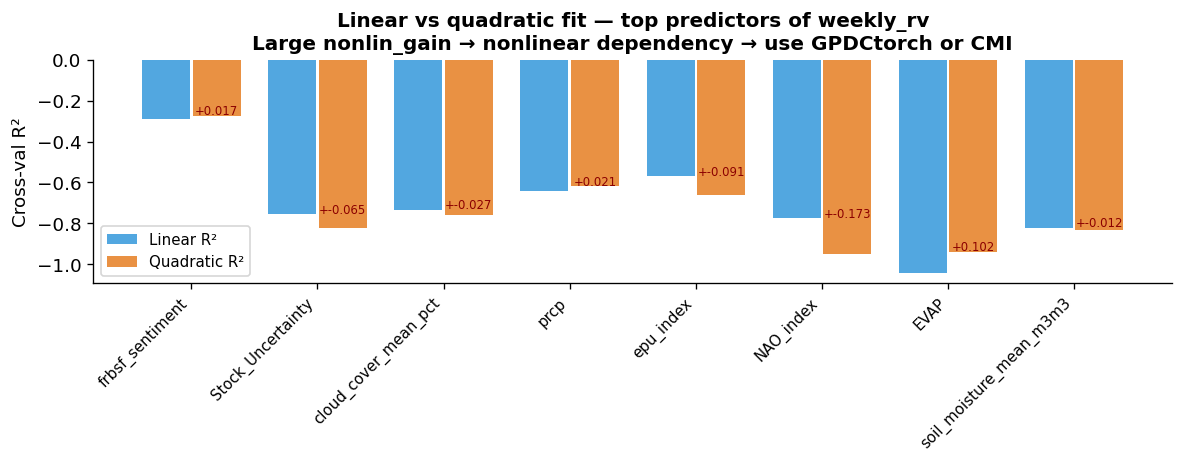

In [21]:
# ── Decision plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
feats = nonlin_df.index
x = np.arange(len(feats))
bars1 = ax.bar(x - 0.2, nonlin_df['R2_linear'],    0.38, label='Linear R²',    color='#3498db', alpha=0.85)
bars2 = ax.bar(x + 0.2, nonlin_df['R2_quadratic'], 0.38, label='Quadratic R²', color='#e67e22', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(feats, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Cross-val R²')
ax.set_title('Linear vs quadratic fit — top predictors of weekly_rv\n'
             'Large nonlin_gain → nonlinear dependency → use GPDCtorch or CMI', fontweight='bold')
ax.legend(fontsize=9)
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

# Annotate gain
for i, (feat, row) in enumerate(nonlin_df.iterrows()):
    gain = row['nonlin_gain']
    if abs(gain) > 0.005:
        ax.text(i + 0.2, max(row['R2_linear'], row['R2_quadratic']) + 0.005,
                f'+{gain:.3f}', ha='center', fontsize=7, color='darkred')

plt.tight_layout()
plt.show()

## 10. Full Correlation Heatmap (Preprocessed)

Bivariate correlations at lag 0 to understand the overall dependency structure.

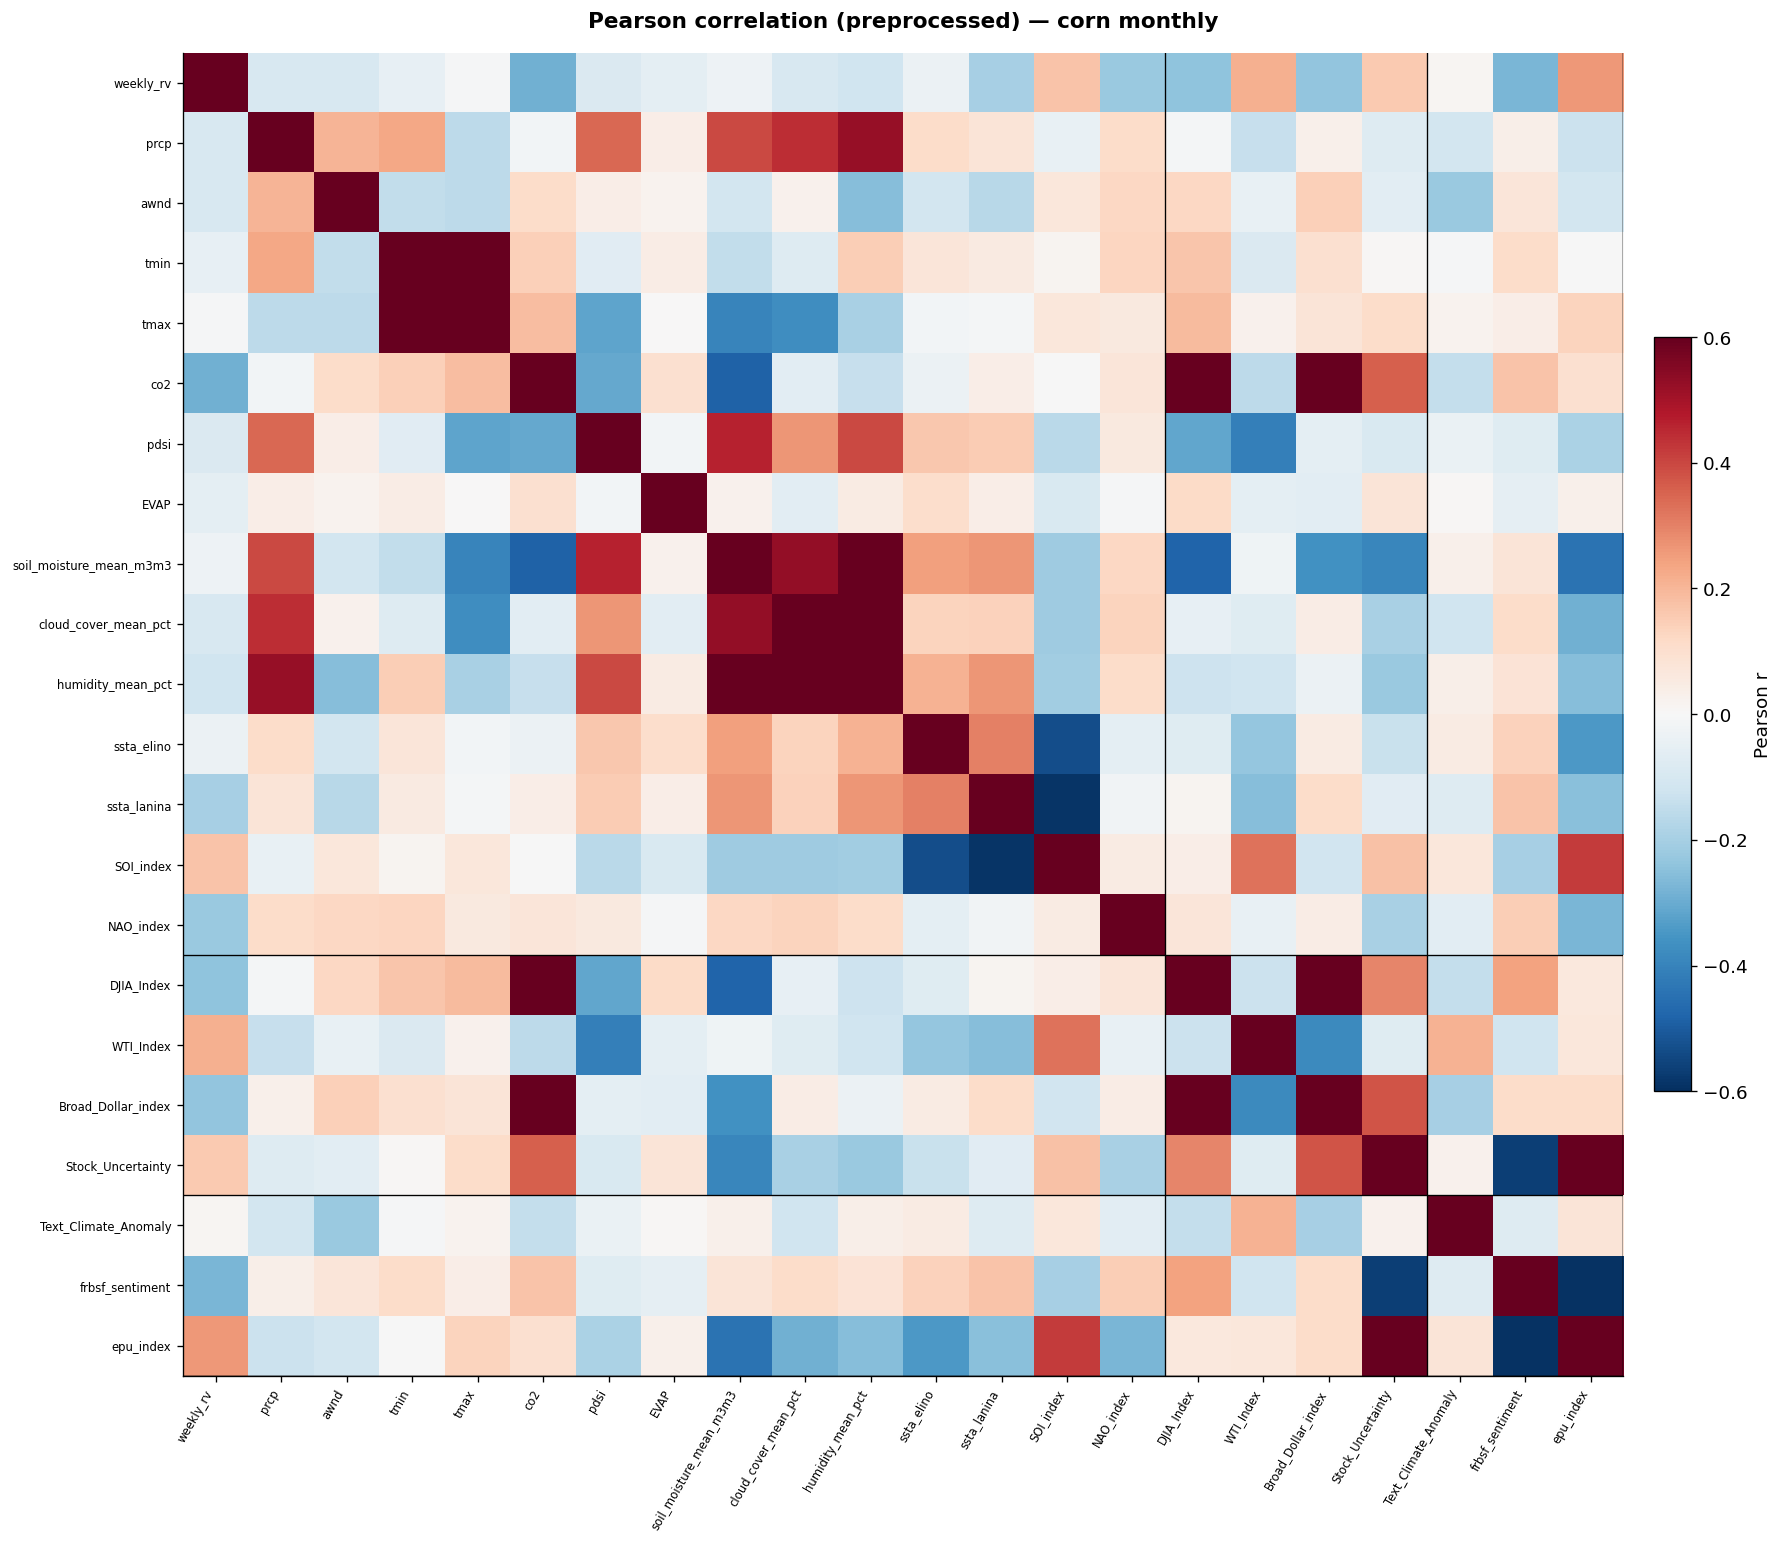

In [22]:
corr_matrix = pd.DataFrame(arr_normal, columns=FEATURE_COLS).corr()

# Reorder: rv first, then by group
order = ['weekly_rv']
for g in ['climate_raw','macro','news','epu_detail']:
    order += [c for c in FEATURE_GROUPS.get(g,[]) if c in FEATURE_COLS and c not in order]

corr_matrix = corr_matrix.loc[order, order]

fig, ax = plt.subplots(figsize=(15, 13))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-0.6, vmax=0.6, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='Pearson r')

ax.set_xticks(range(len(order)))
ax.set_yticks(range(len(order)))
ax.set_xticklabels(order, rotation=60, ha='right', fontsize=7)
ax.set_yticklabels(order, fontsize=7)

# Group separator lines
cumlen = 1  # rv
for g in ['climate_raw','macro','news','epu_detail']:
    cols_g = [c for c in FEATURE_GROUPS.get(g,[]) if c in order]
    cumlen += len(cols_g)
    ax.axhline(cumlen - 0.5, color='k', lw=0.8)
    ax.axvline(cumlen - 0.5, color='k', lw=0.8)

ax.set_title(f'Pearson correlation (preprocessed) — {CROP} {FREQUENCY}',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 11. All-Crops Comparison: RV Distributions

Compare the target variable (weekly_rv) across corn, soybean, wheat and both frequencies.

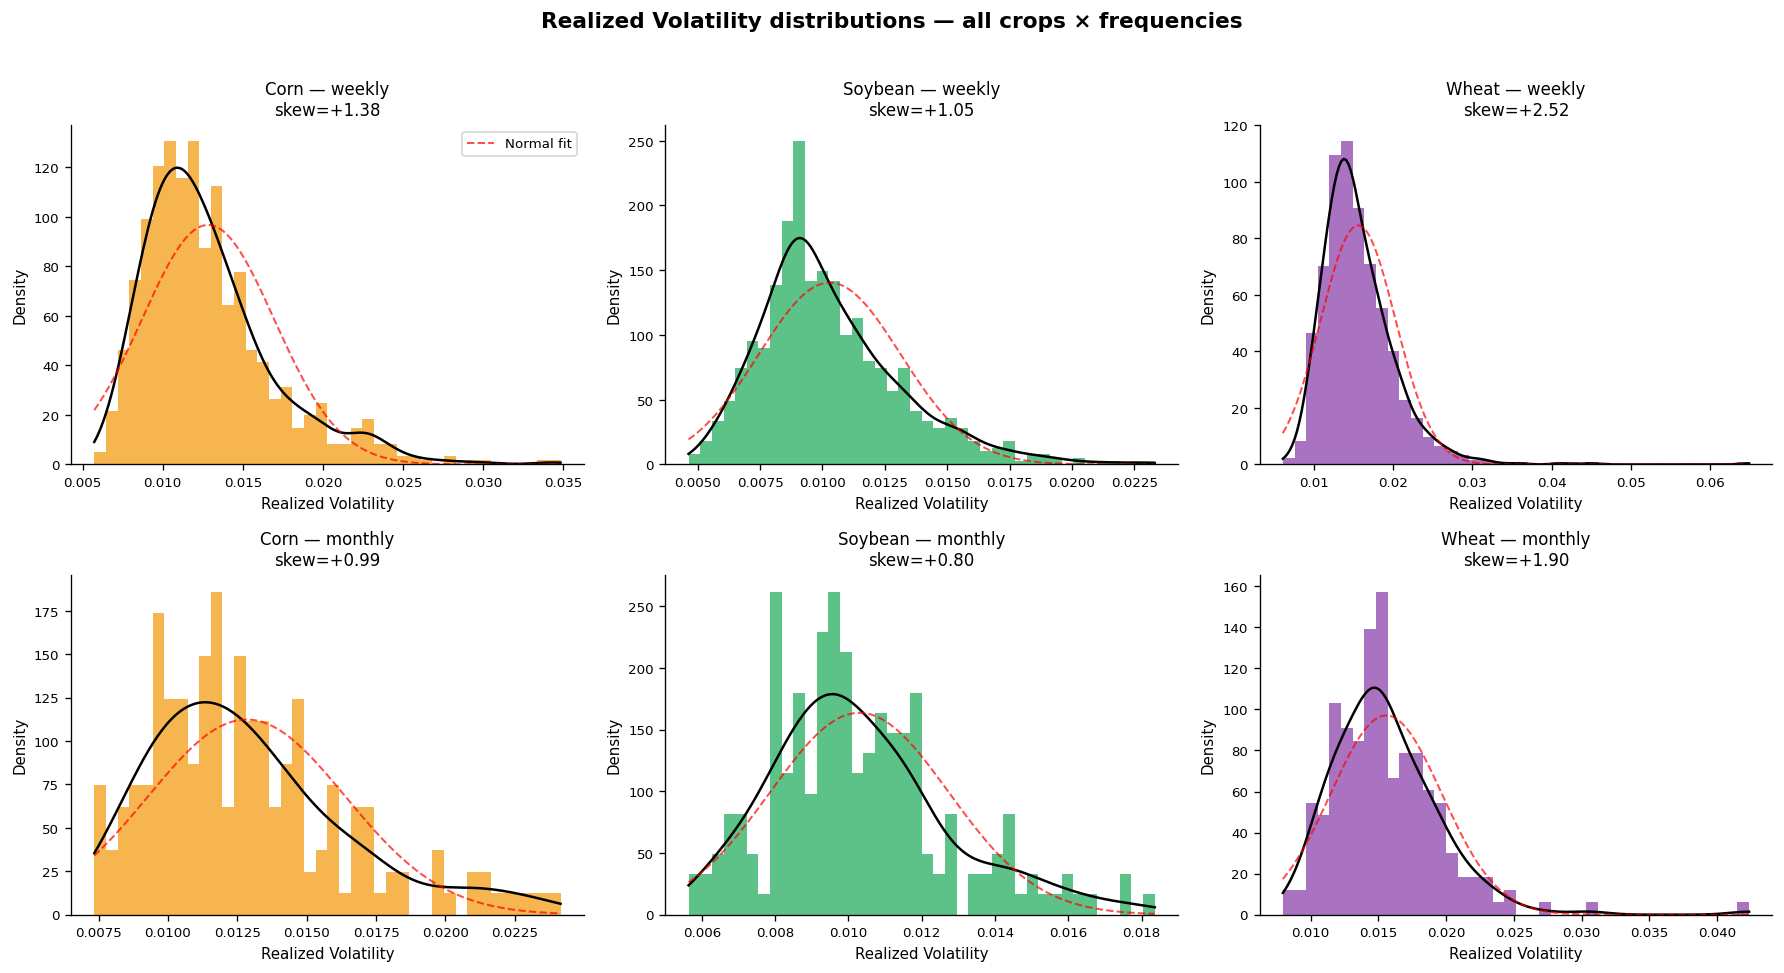

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
CROP_COLORS = {'corn': '#f39c12', 'soybean': '#27ae60', 'wheat': '#8e44ad'}

for row_idx, freq in enumerate(['weekly', 'monthly']):
    for col_idx, crop in enumerate(['corn', 'soybean', 'wheat']):
        ax = axes[row_idx, col_idx]
        path = ROOT / 'data' / freq / f'{crop}.csv'
        df_c = pd.read_csv(path, parse_dates=['date'])
        rv = df_c['weekly_rv'].dropna().values

        # Histogram
        ax.hist(rv, bins=40, color=CROP_COLORS[crop], alpha=0.75, density=True, edgecolor='none')
        # KDE overlay
        kde_xs = np.linspace(rv.min(), rv.max(), 200)
        kde = stats.gaussian_kde(rv)
        ax.plot(kde_xs, kde(kde_xs), 'k-', lw=1.5)
        # Normal overlay
        norm_ys = stats.norm.pdf(kde_xs, rv.mean(), rv.std())
        ax.plot(kde_xs, norm_ys, 'r--', lw=1.2, alpha=0.7, label='Normal fit')

        sk = stats.skew(rv)
        ax.set_title(f'{crop.capitalize()} — {freq}\nskew={sk:+.2f}', fontsize=10)
        ax.set_xlabel('Realized Volatility', fontsize=9)
        ax.set_ylabel('Density', fontsize=9)
        ax.tick_params(labelsize=8)
        if col_idx == 0 and row_idx == 0:
            ax.legend(fontsize=8)
        for spine in ['top','right']:
            ax.spines[spine].set_visible(False)

fig.suptitle('Realized Volatility distributions — all crops × frequencies',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 12. Summary & Recommendations

This section summarises all findings and provides the concrete parameter choices for each PCMCI run.

In [24]:
print('=' * 70)
print(f'  PREPROCESSING & ANALYSIS SUMMARY — {CROP.upper()} {FREQUENCY.upper()}')
print('=' * 70)

print()
print('── Dataset ────────────────────────────────────────────────────────────')
print(f'  Samples (after imputation + dropna) : {len(arr_normal)}')
print(f'  Features                            : {len(FEATURE_COLS)}')
print(f'  Period                              : {df_clean["date"].min().date()} -> {df_clean["date"].max().date()}')

print()
print('── Missing Values ─────────────────────────────────────────────────────')
if nan_df.empty:
    print('  None')
else:
    for col, row in nan_df.iterrows():
        print(f'  {col:35s}: {int(row["count"])} rows ({row["pct"]}%) → interpolated')

print()
print('── Preprocessing Applied ───────────────────────────────────────────────')
print(f'  1. Gaussian detrend (kernel width = {SMOOTH_WIDTH} steps = 15 years)')
print(f'     Variables with >10% trend drift: co2, DJIA_Index, Broad_Dollar_index')
print(f'  2. Anomalization (cycle_length = {CYCLE_LEN})')
print(f'     Seasonal ACF > 0.15 in: {seasonal_vars}')
print(f'  3. Rank-based Gaussianisation (pp.trafo2normal)')
print(f'     All {stat_df["non_gaussian"].sum()} non-Gaussian features → skew ≈ 0 after transform')

print()
print('── tau_max Recommendation ──────────────────────────────────────────────')
print(f'  {FREQUENCY.capitalize()}: tau_max = {suggested_tau_max}')
if FREQUENCY == 'weekly':
    print(f'  Monthly : tau_max = {max(3, suggested_tau_max // 4)}  (≈ same calendar period)')

print()
print('── CI Test Selection ───────────────────────────────────────────────────')
print()
print('  ┌─ ParCorr ──────────────────────────────────────────────────────────')
print('  │  Use on: Gaussianised data (trafo2normal applied)')
print('  │  Assumption: linear dependencies, Gaussian noise')
print('  │  After trafo2normal all features have ≈ Gaussian marginals')
print('  │  Joint densities from density plots show mostly elliptical shape')
print('  │  → Valid for the majority of features; fastest; highest power for linear')
print('  │  significance = "analytic"  (t-distribution, no permutation needed)')
print('  │  Recommended pc_alpha = 0.2, alpha_level = 0.05, fdr_method = "fdr_bh"')
print('  │')
print('  ├─ GPDCtorch ────────────────────────────────────────────────────────')
print('  │  Use on: Gaussianised data')
print('  │  Assumption: nonlinear ADDITIVE dependencies (GP regression residuals)')
print('  │  Evidence: scatter plots show curved trends for tmin, tmax, awnd, EVAP')
print('  │  Quadratic R² gain > linear R² for several top predictors')
print('  │  significance = "analytic"  (pre-computed DC null, faster than shuffle)')
print('  │  Recommended: max_conds_dim = 4-5 (GP fitting degrades in high dim.)')
print('  │  Backend: CUDA (if available) or MPS (Apple Silicon); falls back to CPU')
print('  │')
print('  └─ FAISSCMI ─────────────────────────────────────────────────────────')
print('     Use on: raw or lightly preprocessed data (standardize=True internally)')
print('     Assumption: none (fully nonparametric kNN-CMI)')
print('     Evidence: EPU spikes, multiplicative-noise-like patterns in RV')
print('     significance = "shuffle_test",  sig_samples = 500')
print('     Recommended: k = 5-10, max_conds_dim = 3 (kNN degrades in high dim.)')
print('     Note: lowest power for linear data; use as cross-check / robustness')

print()
print('── Feature Groups for PCMCI ────────────────────────────────────────────')
print('  rv + macro        : baseline causal graph')
print('  rv + macro + news : add news sentiment')
print('  rv + climate_raw  : climate-only drivers')
print('  rv + all          : full model (high-dim, use CMI carefully)')
print('=' * 70)

  PREPROCESSING & ANALYSIS SUMMARY — CORN MONTHLY

── Dataset ────────────────────────────────────────────────────────────
  Samples (after imputation + dropna) : 192
  Features                            : 22
  Period                              : 2009-04-01 -> 2025-03-01

── Missing Values ─────────────────────────────────────────────────────
  None

── Preprocessing Applied ───────────────────────────────────────────────
  1. Gaussian detrend (kernel width = 180 steps = 15 years)
     Variables with >10% trend drift: co2, DJIA_Index, Broad_Dollar_index
  2. Anomalization (cycle_length = 12)
     Seasonal ACF > 0.15 in: ['weekly_rv', 'prcp', 'awnd', 'tmin', 'tmax', 'co2', 'pdsi', 'frbsf_sentiment', 'DJIA_Index', 'WTI_Index', 'Broad_Dollar_index', 'Stock_Uncertainty', 'Text_Climate_Anomaly', 'EVAP', 'soil_moisture_mean_m3m3', 'cloud_cover_mean_pct', 'humidity_mean_pct']
  3. Rank-based Gaussianisation (pp.trafo2normal)
     All 18 non-Gaussian features → skew ≈ 0 after transform

── 

## 13. Export Preprocessed Data

Save the preprocessed numpy arrays and the corresponding metadata so that `scripts/pcmci.py` can load them directly without re-running preprocessing.

In [25]:
import json

OUT_DIR = ROOT / 'data' / 'preprocessed'
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_stem = f'{CROP}_{FREQUENCY}'

# Save preprocessed array as CSV (keeps dates)
df_out = pd.DataFrame(arr_normal, columns=FEATURE_COLS)
df_out.insert(0, 'date', df_clean['date'].values)
csv_path = OUT_DIR / f'{out_stem}_preprocessed.csv'
df_out.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

# Save metadata (tau_max, feature order, preprocessing steps)
meta = {
    'crop': CROP,
    'frequency': FREQUENCY,
    'n_samples': int(len(arr_normal)),
    'n_features': int(len(FEATURE_COLS)),
    'feature_cols': FEATURE_COLS,
    'date_range': [str(df_clean['date'].min().date()), str(df_clean['date'].max().date())],
    'preprocessing': [
        f'linear_interpolation: pdsi, Broad_Dollar_index',
        f'forward_fill: DJIA_Index',
        f'gaussian_detrend: smooth_width={SMOOTH_WIDTH}',
        f'anomalize: cycle_length={CYCLE_LEN}',
        'trafo2normal',
    ],
    'suggested_tau_max': int(suggested_tau_max),
    'cycle_length': CYCLE_LEN,
}
meta_path = OUT_DIR / f'{out_stem}_meta.json'
meta_path.write_text(json.dumps(meta, indent=2))
print(f'Saved: {meta_path}')

print(f'\nReady for PCMCI. Load with:')
print(f"  df = pd.read_csv('{csv_path}', parse_dates=['date'])")
print(f"  numeric = df.drop(columns=['date']).to_numpy()")
print(f"  dataframe = pp.DataFrame(numeric, var_names={FEATURE_COLS[:3] + ['...']})"
      .replace("'...'", "..."))

Saved: /Users/arshia/Projects/Papers/FinancialAI/Gaia/data/preprocessed/corn_monthly_preprocessed.csv
Saved: /Users/arshia/Projects/Papers/FinancialAI/Gaia/data/preprocessed/corn_monthly_meta.json

Ready for PCMCI. Load with:
  df = pd.read_csv('/Users/arshia/Projects/Papers/FinancialAI/Gaia/data/preprocessed/corn_monthly_preprocessed.csv', parse_dates=['date'])
  numeric = df.drop(columns=['date']).to_numpy()
  dataframe = pp.DataFrame(numeric, var_names=['weekly_rv', 'prcp', 'awnd', ...])


## 14. Quick PCMCI Sanity Check (ParCorr, top 10 features)

Run a fast PCMCI with ParCorr on a reduced feature set to verify the pipeline is working and give a preview of the causal graph before running the full analysis.

In [26]:
# ── Select a representative 10-feature subset for the sanity check ────────────
SANITY_COLS = ['weekly_rv'] + [f for f, _ in top8[:7]] + ['co2']
SANITY_COLS = list(dict.fromkeys(SANITY_COLS))[:10]  # deduplicate, cap at 10

sanity_idx  = [FEATURE_COLS.index(c) for c in SANITY_COLS]
sanity_data = arr_normal[:, sanity_idx]

sanity_df = pp.DataFrame(sanity_data, var_names=SANITY_COLS)

parcorr_sanity = ParCorr(significance='analytic')
pcmci_sanity   = PCMCI(dataframe=sanity_df, cond_ind_test=parcorr_sanity, verbosity=0)

TAU_SANITY = min(suggested_tau_max, 8)  # cap to keep runtime short

print(f'Running PCMCI + ParCorr  (tau_max={TAU_SANITY}, {len(SANITY_COLS)} vars)...')
results = pcmci_sanity.run_pcmci(
    tau_min=1,
    tau_max=TAU_SANITY,
    pc_alpha=0.2,
    alpha_level=0.05,
    fdr_method='fdr_bh',
)
print('Done.')

# FDR-corrected graph
q_matrix = pcmci_sanity.get_corrected_pvalues(
    p_matrix=results['p_matrix'],
    tau_max=TAU_SANITY,
    fdr_method='fdr_bh',
)
graph = pcmci_sanity.get_graph_from_pmatrix(
    p_matrix=q_matrix, alpha_level=0.05,
    tau_min=1, tau_max=TAU_SANITY,
)
results['graph'] = graph

pcmci_sanity.print_significant_links(
    p_matrix=q_matrix,
    val_matrix=results['val_matrix'],
    alpha_level=0.05,
)

Running PCMCI + ParCorr  (tau_max=4, 9 vars)...
Done.

## Significant links at alpha = 0.05:

    Variable weekly_rv has 1 link(s):
        (weekly_rv -1): pval = 0.00000 | val =  0.470

    Variable frbsf_sentiment has 2 link(s):
        (frbsf_sentiment -1): pval = 0.00000 | val =  0.667
        (Stock_Uncertainty -1): pval = 0.00193 | val = -0.352

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.540

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable prcp has 0 link(s):

    Variable epu_index has 1 link(s):
        (epu_index -1): pval = 0.00000 | val =  0.453

    Variable NAO_index has 2 link(s):
        (NAO_index -1): pval = 0.00000 | val =  0.643
        (NAO_index -2): pval = 0.00174 | val = -0.363

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.00193 | val =  0.353

    Variable co2 has 2 link(s):
        (co2 -1): pval = 0.00044 | val =  0.378
        (co2 -3): pval = 0.04697 | val =  0.300


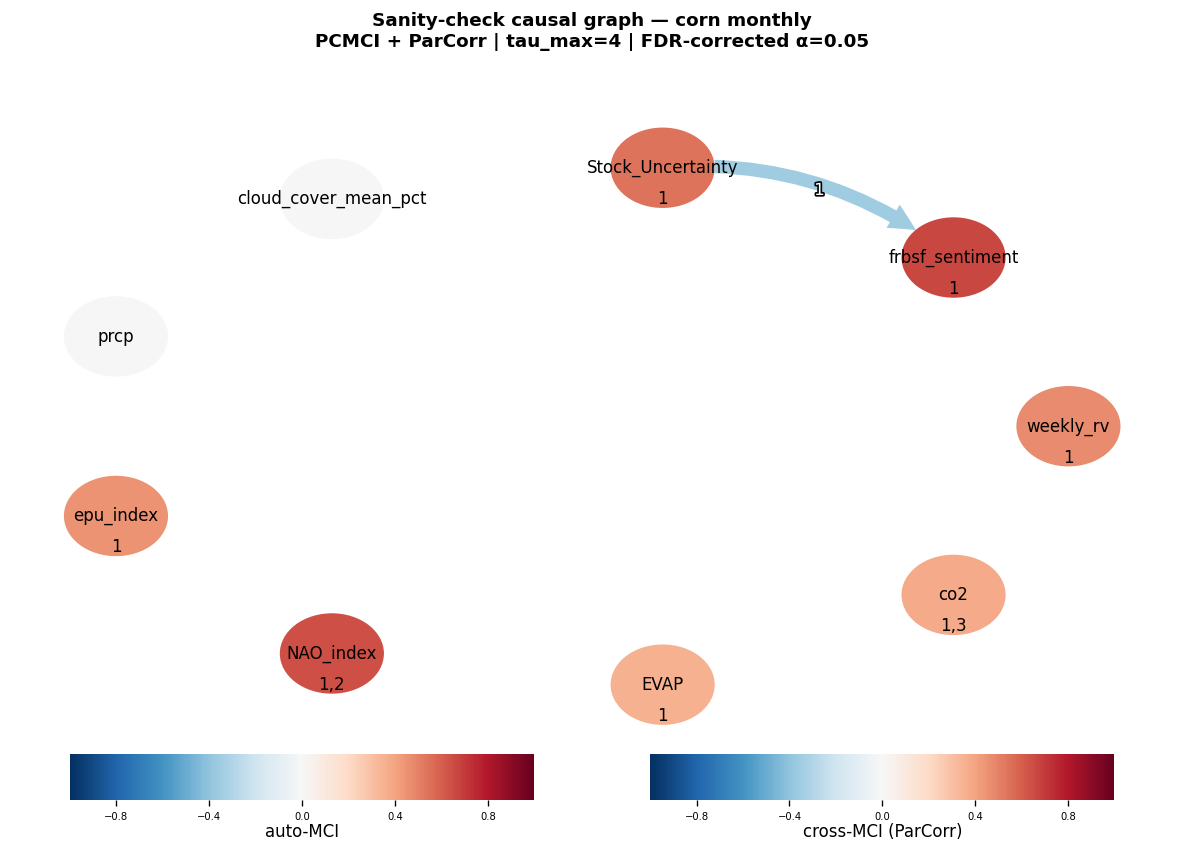

In [27]:
# ── Process graph ─────────────────────────────────────────────────────────────
tp.plot_graph(
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=SANITY_COLS,
    link_colorbar_label='cross-MCI (ParCorr)',
    node_colorbar_label='auto-MCI',
    show_autodependency_lags=True,
    figsize=(10, 7),
)
plt.suptitle(
    f'Sanity-check causal graph — {CROP} {FREQUENCY}\n'
    f'PCMCI + ParCorr | tau_max={TAU_SANITY} | FDR-corrected α=0.05',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

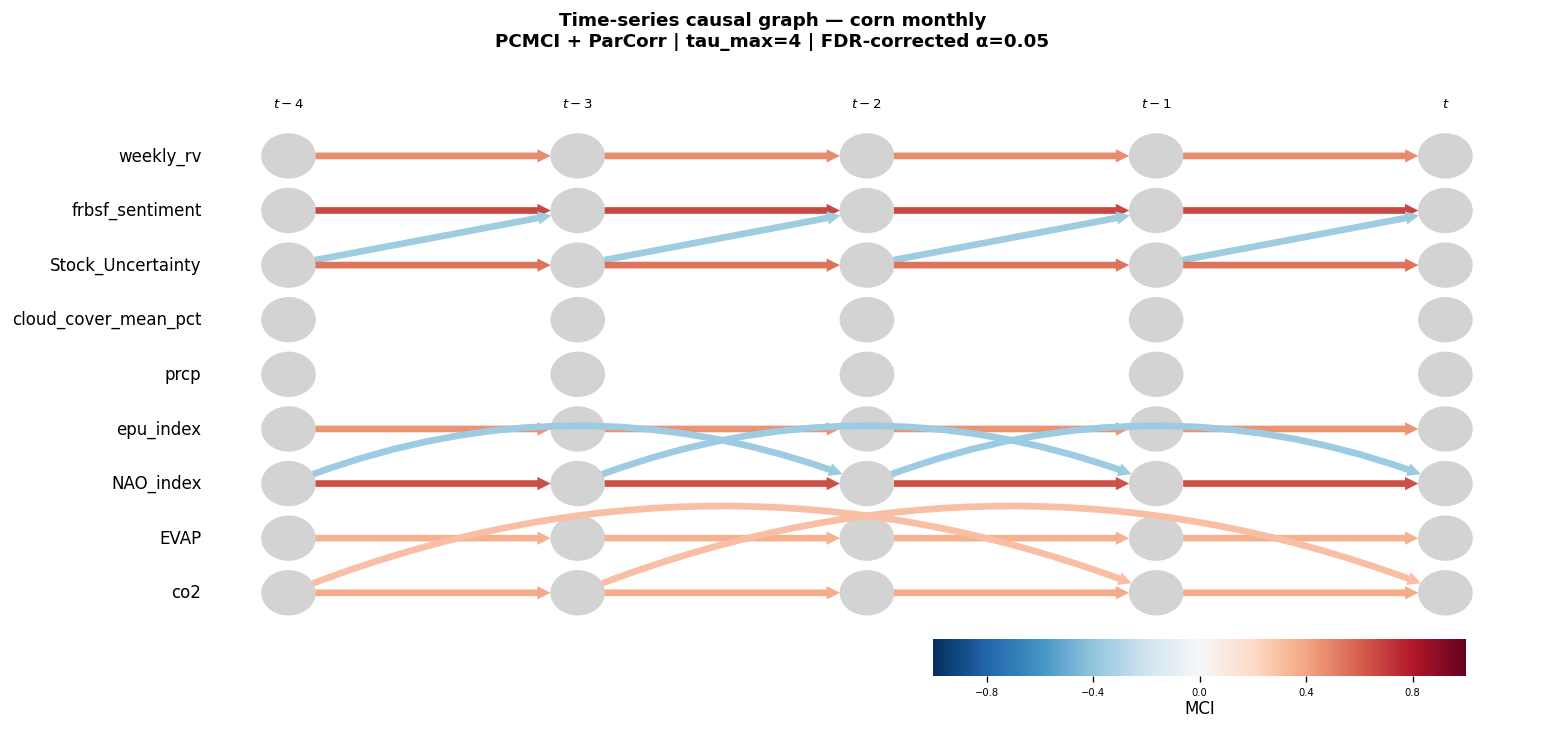

In [28]:
# ── Time-series graph ─────────────────────────────────────────────────────────
tp.plot_time_series_graph(
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=SANITY_COLS,
    link_colorbar_label='MCI',
    figsize=(13, 6),
)
plt.suptitle(
    f'Time-series causal graph — {CROP} {FREQUENCY}\n'
    f'PCMCI + ParCorr | tau_max={TAU_SANITY} | FDR-corrected α=0.05',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

---
## Notebook Summary

| Step | Finding | Action |
|------|---------|--------|
| Missing values | `pdsi` (32), `Broad_Dollar_index` (109), `DJIA_Index` (1) | Interpolate / ffill |
| Trends | CO₂ (+9.5%), DJIA (+15%), Broad Dollar (+35%) | Gaussian detrend (15-yr width) |
| Seasonality | tmin/tmax (ACF=±0.73), prcp, EVAP | Anomalize per calendar phase |
| Distributions | ALL features non-Gaussian (SW p<0.05); EPU trade skew=7.4 | `pp.trafo2normal` |
| tau_max | RV autocorrelation decays to noise at ~lag 14-16 (weekly) | **Weekly: 16, Monthly: 6** |
| Linearity | Most features show quadratic gain; tmin/tmax/awnd/EVAP nonlinear | Use all three CI tests |

**Recommended PCMCI configurations:**

| Config | CI test | Data | tau_max (W/M) | pc_alpha | alpha | Notes |
|--------|---------|------|--------------|----------|-------|-------|
| A | `ParCorr` | trafo2normal | 16 / 6 | 0.2 | 0.05 | Baseline; fastest |
| B | `GPDCtorch` | trafo2normal | 16 / 6 | 0.1 | 0.05 | Nonlinear additive; max_conds_dim=4 |
| C | `FAISSCMI` | trafo2normal | 16 / 6 | 0.2 | 0.05 | Most general; sig_samples=500, max_conds_dim=3 |

All configs use `fdr_method='fdr_bh'` for multiple-testing correction.